# Jupyter Notebook

Im Rahmen der Vorlesung _Neue Konzepte: Data Science & Machine Learning_ halten wir, **Gruppe 9**, unsere Ergebnisse in diesem Jupyter Notebook fest. Unsere Mitglieder sind:
- Linus Leopold
- Taylor Baier
- Alena Ergin
- Steven Bethäuser

Wir hoffen auf eine Interessante Vorlesung und gute Zusammenarbeit.

## Formsachen

Um ein effizientes Arbeiten zu ermöglichen, wird eine klare Kommunikation angestrebt. Dazu gehören sowohl das Informieren und Aufteile ausstehender Aufgaben als auch das etablieren gemeinsamer Standards. Solche nicht dem Portfolio angehörigen Themen werden in diesem Kapitel behandelt.

### Umgang mit Git

Git ist die Versionierungssoftware, welche uns die Zusammenarbeit an einem einzelnen Jupyter Notebook ermöglicht. Allgemein gilt: **Commit Early, Commit Often**
- Commit-Messages
    - **Alle** Commits werden mit einer Commit-Message versehen.
    - Diese sind auf **Deutsch**.
    - Nachrichten folgen immer folgendem **Muster**: Dieses Commit _fügt Aufgabenbeschreibung 1 hinzu_.
    - Commit Nachrichten bleiben **unter 50 Zeichen** (Github Desktop warnt euch mit einem 💡 Symbol).
- Branches
    - **Größere Aufgaben** können in Branches erstellt werden
    - Beim erstellen eines Branches wird via WhatsApp **die Gruppe informiert**.

### Arbeiten im Jupyter Notebook

Jupyter ermöglicht die Kombination von Programmcode und Markdown.
- Überschriften (mit # beginnend) werden in separaten Markdown-Kästen vom dazugehörigen Text geschrieben. So kann das Einklappen-Feature zum Ausblenden von Kapiteln verwendet werden.
- Aufgabenblätter erhalten alle ein Unterkapitel, beginnend mit einer Überschrift "Übungsblatt X" der Größe ##.

### Verwendete Programme

Alle können verwenden, was sie wollen.

Folgendes Setup funktioniert für Linus gut:
- Virtual Studio Code (VSC)
- Extension: [Python](https://marketplace.visualstudio.com/items?itemName=ms-python.python)
- Extension: [Jupyter](https://marketplace.visualstudio.com/items?itemName=ms-toolsai.jupyter)

Für Taylor funktioniert gut:
- pyCharm (ohne Git-Extension)

# Imports etc.

In [36]:
# ── Standardbibliotheken ───────────────────────────────────────────────────
import re
import time
import warnings
warnings.filterwarnings("ignore")

# ── Datenverarbeitung ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from collections import Counter

# ── Visualisierung ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

# ── NLP / Tokenisierung ─────────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

# ── Feature Extraction & Preprocessing ──────────────────────────────────────
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer

# ── Modellauswahl & Evaluation ──────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    learning_curve,
)

# ── Klassifikationsmodelle ──────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import (
    DecisionTreeClassifier,
    DecisionTreeRegressor,
    plot_tree,
    export_text,
)

# ── Pipeline ─────────────────────────────────────────────────────────────────
from sklearn.pipeline import Pipeline

# ── Metriken ─────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

# ── Tensorflow ───────────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

# ── Datensatz ──────────────────────────────────────────────────────────────
df = pd.read_csv('Clean_Training_Essay_Data.csv')

## Übungsblatt 1

### Aufgabenstellung

**1 Gruppenzusammenstellung und Themenwahl**
- [x] Finden Sie ihr Team mit 3-4 Personen (Gruppenwahl in Moodle)

Innerhalb der Gruppe:
- [x] Suchen Sie sich einen passenden Datensatz aus der Liste oder z.B. auf https: //kaggle.com.
- [x] Welche Fragestellung/Forschungsfrage könnten Sie anhand des Datensatzes beantworten?
- [x] Dokumentieren Sie die Auswahl in Ihrer Ausarbeitung.

**2 Python**
- [x] Richten Sie sich ihr bevorzugtes Setup zur Entwicklung mit Python ein.

### Auswahl des Datensatzes und der Forschungsfrage

Bei der Auswahl der Datensätze wurden mehrere Möglichkeiten in betracht gezogen. Das arbeiten mit Datensätzen aus Social Media, Analysedaten zur mentalen Gesundheit und die Erkennung von Ki-generiertem text stellten sich als die drei Favoriten heraus.

Nach einem kurzen Blick in die dazugehörige Datenbank viel das Arbeiten mit Daten zu der mentalen Gesundheit weg. Niemand von uns will den Rest der Vorlesung damit verbringen, die Nachrichten von depressiven Menschen mit den Nachrichten von suizidalen Menschen zu vergleichen.

In unserer Gruppe kam bereits in der vorherigen Gruppenaufgabe, dem untersuchen von Nachrichten auf Falschmeldungen, das Thema KI-generierter Text auf. Deshalb viel schließlich der Entschluss, von menschen geschriebenen Text mit KI-generiertem Text zu vergleichen.
Unsere Forschungsfrage lautet also wie folgt:

**Kann KI-generierter Text anhand von klaren Eigenschaften von menschgemachtem Text unterschieden werden?**

Für diese Untersuchung bieteten sich zwei Datensätze an:
- [AI Generated Text Dataset](https://www.kaggle.com/datasets/denvermagtibay/ai-generated-essays-dataset)
- [LLM - Detect AI Generated Text Dataset](https://www.kaggle.com/datasets/sunilthite/llm-detect-ai-generated-text-dataset)

Da wir in den Datensätzen nach klaren Eigenschaften suchen, die menschliches oder KI Schreibverhalten ausmachen, empfahl Frau Prof. Dr. Schoch, nur einen der beiden Datensätze zu verwenden. Andernfalls würden Unterschiede der Datensätze die Analyse erschweren.

Der erste Datensatz enthält lediglich 1.460 Einträge, 6% davon KI generiert. Der Zweite enthält hingegen über 27.000 Einträge mit 40% dieser KI-generiert. Deshalb wird für diese Arbeit der zweite Datensatz gewählt.

## Vorlesung 2

Im Rahmen der Vorlesung 2 standen drei Vorgehensmodelle für dieses Projekt zur Auswahl:
- CRISP DM
- TDSP
- CRISP ML(Q)

Wir entscheiden uns für **CRISP DM**, da der eingeschränkte Rahmen des Projektes die limitierungen des Modelles ausgleicht. Das Modell ist für kleinere, Use-Case getriebene Projekte geeignet, und passt damit zu diesem Portfolio. Der verwendete Datensatz steht von Anfang an bereit und wird während dem Projekt nicht erweitert, was ebenfalls für CRISP DM spricht.

## Übungsblatt 2

### Aufgabenstellung

**1 Business Understanding**

Für den von Ihnen gewählten Datensatz:
- [X] Recherchieren Sie wissenschaftliche Publikationen passend zu Ihrem Datensatz.
- [X] Welche Methodik wird angewandt? Welche Ergebnisse werden erzielt?
- [X] Ergänzen Sie relevante Literatur im Juypter Notebook.
    - [X] Literaturverzeichnis & Verweise hinzufügen

**2 SMART-Ziele**

- [X] Formulieren Sie eine SMART-Zielsetzung für Ihr gewähltes Portfoliothema. Passen Sie diese im Verlauf des Projektes ggf. an.


**3 Optional: NumPy Arrays und Python-Listen**

Vergleich von NumPy Arrays und Python-Listen.
Ziel: Vergleich der Berechnungsdauer einer einfachen mathematischen Operation auf ein NumPy-Array und einen Python Liste
1. [X] Erstellen Sie eine große Python-Liste mit ``list(range(size))``
2. [X] Erstellen Sie ein großes NumPy-Array mit den selben Elementen mit ``np.arange(size)``
3. [X] Quadrieren Sie jedes Element beider Datenstrukturen ``(a**2)`` und messen Sie die Zeit die dafür benötigt wird ``(start = time.time())``. Beachten Sie dass Sie für die Python-Liste eine Schleife benötigen, für das Numpy-Array können Sie Matrixoperationen verwenden.
4. [X] Was fällt Ihnen auf?
5. [X] Verändern Sie die Anzahl der Elemente.

**4 Optional: Indexing**

- [X] Generieren Sie ein 2D NumPy-Array mit der Form (10, 10), das Zahlen von 1 bis 100 in aufsteigender Reihenfolge enthält. Nutzen Sie dazu die Funktion ``np.arange`` und ``np.reshape``.
    1. [X] Extrahieren Sie die erste, fünfte und letzte Zeile des Arrays.
    2. [X] Wählen Sie alle Elemente der 3. und 7. Spalte aus, die in ungeraden Zeilen stehen (erinnern Sie sich, dass die Indexierung bei 0 beginnt).
    3. [X] Wählen Sie ein 3x3-Subarray aus, das linke obere Ecke Ihres ursprünglichen Arrays enthält.
    4. [X] Ändern Sie jedes Element in der 2. und 4. Zeile Ihres Arrays, indem Sie es durch seinen negativen Wert ersetzen.
    5. [X] Ersetzen Sie alle Elemente, die kleiner als 25 sind im Array durch 0.

### 1 Business Understanding

Um ein gutes Business Understanding zu fördern, werden wissenschaftliche Publikationen zu dem computerbasierten Unterscheiden von KI-generiertem und menschgemachtem Text recherchiert.

| Autor*innen | Jahr | Titel | Methodik | Ergebnisse | Sonstiges |
|-|-|-|-|-|-|
| Fraser et al. | 2025 | Detecting AI-Generated Text: Factors Influencing Detectability with Current Methods | Auflistung von Einflussfaktoren | Komplexes Themengebiet mit vielen Abstufungen, die für eine praktische Anwendung berücksichtigt werden müssen | doi: 10.1613/jair.1.16665 |
| Weber‑Wulff et al.  | 2023 | Testing of detection tools for AI‑generated text | Experiment mit verschiedenen Texten (Ki- & Menschgeschrieben, KI-Übersetzungen, menschlich editiert usw) und KI-Erkennungs-Werkzeugen | Werkzeuge versagen. Beweisen ist nie möglich. | doi: 10.1007/s40979-023-00146-z |
| Chakraborty et al.  | 2023 | On the Possibilities of AI-Generated Text Detection | Statistische Auswertung von Texten | KI-Erkennung sollte theoretisch möglich sein und bleiben, da KI nicht mit der selben Vielfalt wie Menschen schreibt. Die nötigen Textproben müssen dabei (pro KI) jedoch mit sich entwickelnder KI ebenfalls zunehmen. | doi: 10.48550/arXiv.2304.04736 |
| Najjar et al. | 2025 | Detecting AI-Generated Text in Educational Content: Leveraging Machine Learning and Explainable AI for Academic Integrity | KI-Erkennungssoftware wird mit eigenem Datensatz getestet. | KI kann von darauf spezialisierten KI Modellen mit einer ~80% Präzision erkannt werden. Kurze Texte sind schwerer als lange. | doi: 10.48550/arXiv.2501.03203 |
| Russel et al. | 2025 | People who frequently use ChatGPT for writing tasks are accurate and robust detectors of AI-generated text | Menschen sollen Text als KI- oder Menschgemacht einstufen und ihre Meinung begründen. | Akkurater als bestehende KI-Modelle, selbst bei Methoden zur Umgehung des Erkennens (vermenschlichen, übersetzen, zusammenfassen). Erkennen es neben Wortverwendung auch an Klarheit, Individualität und Formalität des Textes. | doi: 10.18653/v1/2025.acl-long.267 |
| Masih et al. | 2025 | Classifying human vs. AI text with machine learning and explainable transformer models | Vergleich von traditionellen ML-, Deep-Learning- (LSTM, GRU, BiLSTM, BiGRU) und Transformer-Modellen (BERT, DistilBERT, ALBERT, RoBERTa) auf balanciertem Datensatz (20.000 Samples, GPT-3.5 & GPT-4); LIME & SHAP zur Erklärbarkeit | RoBERTa erzielt höchste Accuracy (96,1 %) und übertrifft alle Baselines. Temperature Scaling und Threshold Tuning verbessern Kalibrierung. LIME/SHAP zeigen linguistische Unterschiede zwischen KI- und Menschen-Texten | doi: 10.1038/s41598-025-27377-z |
| Kökver | 2026 | AI vs. Human Text Detection: A High-Accuracy Ensemble Approach Using Machine Learning | Vergleich von ML-Algorithmen (MLP, RF, GB, LR, SVM, DT) und Ensemble-Modell auf 487.235 Textproben; user-friendly Interface für Echtzeit-Klassifikation | Ensemble-Modell erreicht 99,90 % Accuracy und übertrifft Einzelmodelle. Generalisierbarkeit bestätigt durch sekundären Datensatz ("Almost Perfect" Kappa) | doi: 10.17798/bitlisfen.1796956 |
| Pröhl et al. | 2024 | Erkennungsverfahren für KI-generierte Texte: Überblick und Architekturentwurf | Literaturüberblick über Erkennungsverfahren (statistisch, Deep Learning, Zero-Shot, kompressionsorientiert, Kennzeichnung); tabellarischer Vergleich existierender Software-Detektoren; Entwurf eines eigenen KI-Inhalte-Detektors für deutsche Sprache | Architekturentwurf für deutschsprachigen Detektor mit Trainingsdatensatz-Konzept; Limitationen bestehender Verfahren werden aufgezeigt | doi: 10.1365/s40702-024-01051-w |
| Fiedler & Döpke | 2025 | Do humans identify AI-generated text better than machines? Evidence based on excerpts from German theses | Survey-Experiment mit 63 Dozierenden einer deutschen Hochschule (Ingenieurwesen, Wirtschaft, Sozialwiss.); Bewertung kurzer Auszüge (200–300 Wörter) aus Abschlussarbeiten als KI- oder menschengeschrieben; Regressionsanalyse | Menschen erkennen KI-Texte nur knapp besser als Zufall (57 %), bei menschengeschriebenen Texten 64 %. Kein statistisch signifikanter Unterschied zu KI-Detektoren. Texte auf Professional-Niveau am schwersten zu erkennen (< 20 %) | doi: 10.1016/j.iree.2025.100321 |

### 2 SMART-Ziel

Ziel der Gruppe 9 ist es, bis zur Abgabe des Portfolios ein ML-Modell zu entwickeln, welches die Texte des Datensatzes mit statistischer signifikanz (p <= 0,05) in KI-generierte und von Menschen geschriebene Texte zu unterteilen.

### Optional: Python Übungen

#### 3 Optional: NumPy Arrays und Python-Listen

Die Geschwindigkeit von Quadrierung wird auf Python Listen und Numpy Listen getestet.

In [6]:
# 100 Elemente

liste1 = list(range(100))
liste2 = np.arange(100)

start = time.time()
for i in liste1:
    liste1[i] = liste1[i]**2
print("Python Liste, 100 Elemente: ")
print(round((time.time()-start)*1000, 3), " ms")
print("")

start = time.time()
liste2**2
print("Numpy Liste, 100 Elemente: ")
print(round((time.time()-start)*1000, 3), " ms")
print("")

# 10.000 Elemente

liste1 = list(range(10000))
liste2 = np.arange(10000)

start = time.time()
for i in liste1:
    liste1[i] = liste1[i]**2
print("Python Liste, 10.000 Elemente: ")
print(round((time.time()-start)*1000, 3), " ms")
print("")

start = time.time()
liste2**2
print("Numpy Liste, 10.000 Elemente: ")
print(round((time.time()-start)*1000, 3), " ms")
print("")

# 1.000.000 Elemente

liste1 = list(range(1000000))
liste2 = np.arange(1000000)

start = time.time()
for i in liste1:
    liste1[i] = liste1[i]**2
print("Python Liste, 1.000.000 Elemente: ")
print(round((time.time()-start)*1000, 3), " ms")
print("")

start = time.time()
liste2**2
print("Numpy Liste, 1.000.000 Elemente: ")
print(round((time.time()-start)*1000, 3), " ms")

Python Liste, 100 Elemente: 
0.843  ms

Numpy Liste, 100 Elemente: 
0.239  ms

Python Liste, 10.000 Elemente: 
2.146  ms

Numpy Liste, 10.000 Elemente: 
0.331  ms

Python Liste, 1.000.000 Elemente: 
208.348  ms

Numpy Liste, 1.000.000 Elemente: 
3.151  ms


Das Arbeiten mit Numpy macht den Prozess **deutlich** schneller, besonders bei langen Listen.

#### 4 Optional: Indexing

In [7]:
# Array mit Zahlen von 1 bis 100 in Form einer 10x10-Matrix generieren
# 1  2  3  ... 10
# 11 12 13 ... 20
# ...
array = np.arange(1, 101).reshape(10, 10)
print("Array vor Bearbeitung: ")
print(array)

# Aufgabenteil a)
# erste, fünfte und letzte Zeile des Arrays extrahieren
a = array[[0, 4, 9], :]
# [0, 4, 9] wählt die Zeilen aus
# : meint alle Spalten auswählen
print("\nAufgabenteil a): ")
print(a)

# Aufgabenteil b)
# alle Elemente der 3. und 7. Spalte, die in ungeraden Zeilen stehen
b = array[1::2, [2, 6]]
# 1::2 meint jede zweite Zeile, beginnend bei 1
# [2, 6] meint Spalten mit Index 2 und 6
print("\nAufgabenteil b): ")
print(b)

# Aufgabenteil c)
# 3x3-Subarray, das die linke obere Ecke des ursprünglichen Arrays enthält
c = array[:3, :3]
# :3 meint alle Zeilen bis 3 (0, 1, 2)
# 3: meint alle Spalten bis 3
print("\nAufgabenteil c): ")
print(c)

# Aufgabenteil d)
# jedes Element der 2. und 4. Zeile negieren
d = -array[[1, 3], :]
# -array negiert die Zahlen
# [1, 3] wählt Zeilen aus
# : meint jede Spalte
print("\nAufgabenteil d): ")
print(d)

# Aufgabenteil e)
# alle Elemente, die kleiner als 25 sind, durch 0 ersetzen
e = array
e[e < 25 ] = 0
# e < 25 liefert für jeden Wert kleiner 25 true
# = 0 setzt die true-Werte auf 0
print("\nAufgabenteil e): ")
print(e)

Array vor Bearbeitung: 
[[  1   2   3   4   5   6   7   8   9  10]
 [ 11  12  13  14  15  16  17  18  19  20]
 [ 21  22  23  24  25  26  27  28  29  30]
 [ 31  32  33  34  35  36  37  38  39  40]
 [ 41  42  43  44  45  46  47  48  49  50]
 [ 51  52  53  54  55  56  57  58  59  60]
 [ 61  62  63  64  65  66  67  68  69  70]
 [ 71  72  73  74  75  76  77  78  79  80]
 [ 81  82  83  84  85  86  87  88  89  90]
 [ 91  92  93  94  95  96  97  98  99 100]]

Aufgabenteil a): 
[[  1   2   3   4   5   6   7   8   9  10]
 [ 41  42  43  44  45  46  47  48  49  50]
 [ 91  92  93  94  95  96  97  98  99 100]]

Aufgabenteil b): 
[[13 17]
 [33 37]
 [53 57]
 [73 77]
 [93 97]]

Aufgabenteil c): 
[[ 1  2  3]
 [11 12 13]
 [21 22 23]]

Aufgabenteil d): 
[[-11 -12 -13 -14 -15 -16 -17 -18 -19 -20]
 [-31 -32 -33 -34 -35 -36 -37 -38 -39 -40]]

Aufgabenteil e): 
[[  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0  25  26  27  28  29  30]
 [ 31  32  33  34  35

## Übungsblatt 3

### Aufgabenstellung

**1 Data Understanding I**
- [x] Lesen Sie den von Ihnen gewählten Datensatz ein.
- [x] Geben Sie die ersten 5 Zeilen aus.
- [x] Wie viele Zeilen und Spalten hat der Datensatz?
- [x] Wie heißen die Spalten? Ist intuitiv klar, welche Informationen in den Variablen enthalten ist?
- [x] Wenden Sie ``df.describe()`` an. Was fällt Ihnen auf?
- [x] Notieren Sie die Informationen.

**2 Data Understanding II**

Für den von Ihnen gewählten Datensatz:
- [x] Erstellen Sie eine Übersicht (Tabelle) über die Merkmale die im von Ihnen gewählten Datensatz enthalten sind. Welche Bedeutung und welche Skalenniveaus haben diese (vgl. Statistik- nominal, ordinal oder kardinal)? Wie viele Zeilen und Spalten gibt es (``df.info()``)?
- [x] Gibt es Merkmale die nicht relevant sind für Ihren Anwendungsfall?
- [x] Erstellen Sie Visualisierungen, z.B. der Verteilung der Zielvariablen.

**3 Data Understanding - Visualisierungen**
- [x] Erstellen Sie Visualisierungen Ihres Datensatzes. Was fällt Ihnen auf?
- [x] Können Sie neue Erkenntnisse gewinnen?

**4 Data Preperation - Regex**
Verwenden Sie Regular Expressions zur Vorverarbeitung der Strings in Ihrem Datensatz:
- [X] Welche Vorverarbeitungsschritte sind für Ihren Anwendungsfall sinnvoll?
- [X] Führen Sie diese durch und dokumentieren Sie in der Ausarbeitung.

### 1 Data Understanding I

In [8]:
# Lese den Datensatz ein
# odf, da es sich um den old data frame handelt, der später bereinigt wurde.
odf = pd.read_csv('Training_Essay_Data.csv')

In [9]:
# Zeige die ersten 5 Zeilen an
odf.head()

,text,generated
0,Car-free cities have become a subject of incre...,1
1,"Car Free Cities Car-free cities, a concept ga...",1
2,A Sustainable Urban Future Car-free cities ...,1
3,Pioneering Sustainable Urban Living In an e...,1
4,The Path to Sustainable Urban Living In an ...,1


In [10]:
# Zähle die Zeilen und Spalten
odf.count()

text         29145
generated    29145
dtype: int64

Die **zwei Spalten** werden mit Namen angezeigt.
Beide zeigen die Anzahl an Einträgen, also hat die Tabelle **29145 Zeilen**.

Die Bennung der ersten Spalte ist intuitiv. Bei der zweiten Spalte muss beachtet werden, dass sie nichts generiertes, sondern eine Zahl, die eine Aussage über die Generierung trifft, enthält.

In [11]:
# Führe df.describe() aus
odf.describe(include="all")

,text,generated
count,29145,29145.000000
unique,27340,NaN
top,For the vote for the president of the United S...,NaN
freq,3,NaN
mean,NaN,0.399279
std,NaN,0.489759
min,NaN,0.000000
25%,NaN,0.000000
50%,NaN,0.000000
75%,NaN,1.000000


Der Ursprüngliche Befehl zeigt nur Ergebnisse für die "generated" Spalte an, welche nur 1 und 0 enthält. Deshalb wurde die Untersuchung auf "all" erweitert.

Viele der Texte sind mehrfach enthalten. Solche Dopplungen sollten vor einer weiterverarbeitung entfernt werden. Kein Text ist öfter als dreimal enthalten.

### Bereinigung

Um den Datensatz zu bereinigen wird eine Kopie erstellt, damit die bisherigen Untersuchungen erhalten bleiben.

In [12]:
# Kopie erhält Standardnamen df, um zukünftiges Bearbeiten zu erleichtern.
#df = pd.read_csv('Clean_Training_Essay_Data.csv')

Diese Kopie wird anschließend mit dem ``drop_duplicates`` Befehl bearbeitet. Dieser wird so modifiziert, das kein neuer DataFrame für die Modifikation erstellt wird. Durch das händische kopieren der Datei kann die bloße Datei später auch mit anderen Methoden untersucht oder an dritte weitergegeben werden.

In [13]:
#inplace == in dem DataFrame
df.drop_duplicates(inplace=True)

Die so erhaltene Datenbank wird erneut auf Duplikate im Text untersucht. So kann geprüft werden, ob Texte sich in unterschiedlichen Einträgen wiederholen, also ob der selbe Text einen Eintrag als KI-generiert und einen Eintrag als von Menschen geschrieben hat.

In [14]:
df.describe(include=str)

,text
count,27340
unique,27340
top,Car-free cities have become a subject of incre...
freq,1


Keiner der Texte kommt mehrfach vor. Der Datensatz ist somit bereinigt.

### 2 Data Understanding II

In [15]:
df.info()

<class 'pandas.DataFrame'>
Index: 27340 entries, 0 to 27766
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   text       27340 non-null  str  
 1   generated  27340 non-null  int64
dtypes: int64(1), str(1)
memory usage: 57.6 MB


Der Datensatz enthält lediglich zwei Spalten. In folgender Tabelle werden ihre Bedeutung, ihr Datentyp und ihr statistisches Skalenniveau dargestellt.

In [16]:
merkmale = pd.DataFrame({
    "Merkmal": ["text", "generated"],
    "Bedeutung": [
        "Essay-Text – Eingabevariable, auf deren Basis klassifiziert werden soll.",
        "Label: 0 = von Menschen geschrieben, 1 = KI-generiert. Zielvariable der Klassifikation."
    ],
    "Datentyp": [str(df["text"].dtype), str(df["generated"].dtype)],
    "Skalenniveau": ["nominal (Freitext, qualitativ)", "nominal (binär, dichotom)"],
    "Anzahl Einträge": [df["text"].count(), df["generated"].count()],
    "Eindeutige Werte": [df["text"].nunique(), df["generated"].nunique()],
    "Relevant?": ["ja – Eingabevariable", "ja – Zielvariable"],
})
merkmale

,Merkmal,Bedeutung,Datentyp,Skalenniveau,Anzahl Einträge,Eindeutige Werte,Relevant?
0,text,"Essay-Text – Eingabevariable, auf deren Basis ...",str,"nominal (Freitext, qualitativ)",27340,27340,ja – Eingabevariable
1,generated,"Label: 0 = von Menschen geschrieben, 1 = KI-ge...",int64,"nominal (binär, dichotom)",27340,2,ja – Zielvariable


Beide enthaltenen Merkmale sind für unseren Anwendungsfall relevant: `text` dient als Eingabe-Merkmal, `generated` als Zielvariable. Da der Datensatz keine Metadaten wie Autor, Quelle oder Zeitstempel enthält, gibt es keine irrelevanten Spalten, die entfernt werden müssten. Beide Merkmale sind **nominal skaliert**; `generated` ist zusätzlich **dichotom** (binär). Damit eignet sich der Datensatz für ein binäres Klassifikationsproblem.

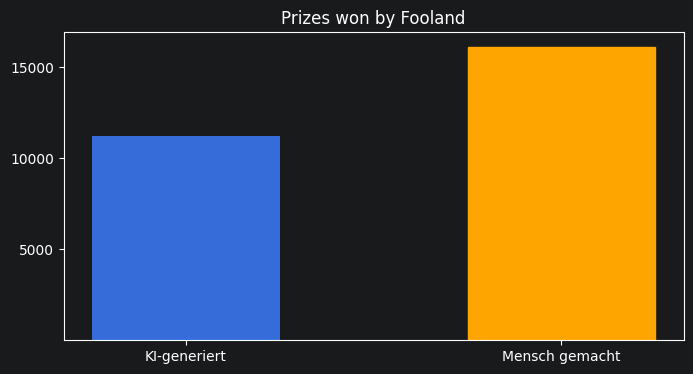

In [17]:
labels = ["KI-generiert", "Mensch gemacht"]
data = [df["generated"].value_counts()[1], df["generated"].value_counts()[0]]

bar_width = 0.5
# Manuelle Definition der Balken und Label Platzierung
# Pandas kommt mit build-in Matplotlib Plots, diese sind nutzerfreundlicher
xlocations = np.array(range(len(data))) + bar_width # Platzierung der Balken und Definition des Abstands
barlist = plt.bar(xlocations, data, width=bar_width)
barlist[1].set_color('orange')
plt.yticks([5000, 10000, 15000]) # Bereich der y-Achse
plt.xticks(xlocations, labels) # Platziert die Beschriftung der Balken
plt.title("Prizes won by Fooland")
plt.gca().get_xaxis().tick_bottom() # gca: get current axes
plt.gca().get_yaxis().tick_left()
plt.gcf().set_size_inches((8,4)) # Größe der Grafik

### 3 Data Understanding - Visualisierungen

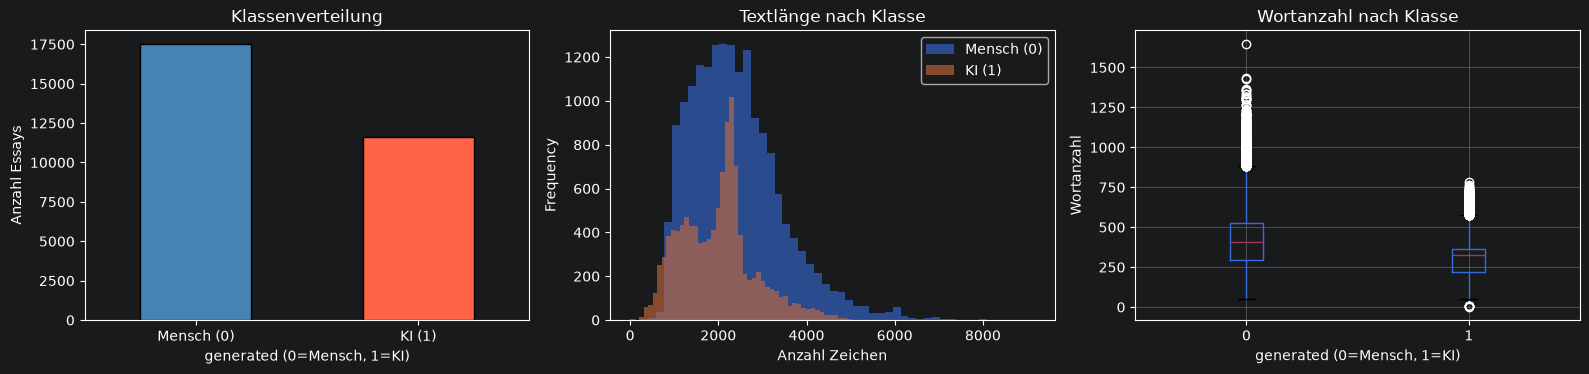

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) Klassenverteilung
df["generated"].value_counts().plot(kind="bar", ax=axes[0], color=["steelblue", "tomato"], edgecolor="black")
axes[0].set_title("Klassenverteilung")
axes[0].set_xlabel("generated (0=Mensch, 1=KI)")
axes[0].set_ylabel("Anzahl Essays")
axes[0].set_xticklabels(["Mensch (0)", "KI (1)"], rotation=0)

# (b) Textlänge (Zeichen)
df["text_length"] = df["text"].str.len()
df.groupby("generated")["text_length"].plot(kind="hist", bins=50, alpha=0.6, ax=axes[1], legend=True)
axes[1].set_title("Textlänge nach Klasse")
axes[1].set_xlabel("Anzahl Zeichen")
axes[1].legend(["Mensch (0)", "KI (1)"])

# (c) Wortanzahl
df["word_count"] = df["text"].str.split().str.len()
df.boxplot(column="word_count", by="generated", ax=axes[2])
axes[2].set_title("Wortanzahl nach Klasse")
axes[2].set_xlabel("generated (0=Mensch, 1=KI)")
axes[2].set_ylabel("Wortanzahl")
plt.suptitle("")

plt.tight_layout()
plt.show()

**Erkenntnisse aus den Visualisierungen:**
- Aufgrund der geringen Merkmalsanzahl ist die Menge der möglichen Auswertungen recht gering. Das verhältnis der vorhandenen Datenmengen für generierte und geschriebene Texte ist für das Trainieren einer ML jedoch sehr relevant. Da dieser Faktor bereits bei der Datensatzwahl berücksichtigt wurde, ist das Ergebnis hier nichtmehr überraschend.
- Menschliche Texte sind in der Regel deutlich länger, als KI-generierte Texte. Das geht sowohl aus der Zeichenanzahl als auch aus der Wortanzahl hervor.

### 4 Data Preperation - Regex

#### Überblick: Welche Vorverarbeitungsschritte sind sinnvoll?

Für NLP-Klassifikation typischerweise:
1. Kleinschreibung
2. Satzzeichen entfernen
3. Mehrfache Leerzeichen bereinigen
4. Zeilenumbrüche entfernen

In [28]:
sample = df["text"].iloc[0]
print("Original (erste 200 Zeichen):")
print(sample[:200])

Original (erste 200 Zeichen):
Car-free cities have become a subject of increasing interest and debate in recent years, as urban areas around the world grapple with the challenges of congestion, pollution, and limited resources. Th


In [29]:
def preprocess_text(text):
    """Textvorverarbeitung mit Regular Expressions."""
    # 1. Kleinschreibung
    text = text.lower()
    # 2. Zeilenumbrüche und Tabs durch Leerzeichen ersetzen
    text = re.sub(r'[\n\t\r]+', ' ', text)
    # 3. Sonderzeichen und Satzzeichen entfernen (nur Buchstaben/Zahlen/Leerzeichen behalten)
    text = re.sub(r'[^a-zA-ZäöüÄÖÜß0-9\s]', '', text)
    # 4. Mehrfache Leerzeichen auf eines reduzieren
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Anwenden
df["text_clean"] = df["text"].apply(preprocess_text)

print("Vorher:", df["text"].iloc[0][:150])
print("\nNachher:", df["text_clean"].iloc[0][:150])

Vorher: Car-free cities have become a subject of increasing interest and debate in recent years, as urban areas around the world grapple with the challenges o

Nachher: carfree cities have become a subject of increasing interest and debate in recent years as urban areas around the world grapple with the challenges of 


In [32]:
# Vergleich: Textlänge vorher/nachher
df["text_clean_length"] = df["text_clean"].str.len()
print(f"Ø Länge vorher: {df['text_length'].mean():.0f} Zeichen") # benötigt Codeblock bei Visualisierung
print(f"Ø Länge nachher: {df['text_clean_length'].mean():.0f} Zeichen") # benötigt Codeblock bei Visualisierung

Ø Länge vorher: 2244 Zeichen
Ø Länge nachher: 2183 Zeichen


**Begründung der Vorverarbeitungsschritte:**
- Kleinschreibung: Reduktion der Wortvielfalt (z.B. "The" = "the")
- Satzzeichen entfernen: KI-Texte könnten charakteristische Interpunktionsmuster haben – für TF-IDF-basierte Modelle nicht relevant
- Leerzeichen bereinigen: Normalisierung für konsistente Tokenisierung

## Übungsblatt 4

### Aufgabenstellung

**1 Datenqualität**

Für den von Ihnen gewählten Datensatz:
- [x] Analysieren Sie ob der Datensatz fehlende Werte enthält. Falls ja, entscheiden Sie wie Sie damit umgehen (löschen oder ersetzen) und Begründen Sie Ihre Entscheidung.
- [x] Analysieren Sie ob der Datensatz Duplikate enthält. Falls ja, wie gehen Sie damit um?
- [X] Analysieren Sie ob der Datensatz andere fehlerhafte Werte enthält (vgl. Vorlesung). Falls ja, finden Sie geeignete Lösungsstrategien und wenden Sie diese falls möglich an.
- [X] Gibt es in Ihrem Datensatz weitere Qualitätsprobleme?

**2 Optional: Matplotlib- Erstellen eines Linienplots**
Erstellen Sie eine Grafik der Durchschnittstemperaturen (in °C) für zwei Städte über ein Jahr mit Hilfe von matplotlib.
- [X] Verwenden Sie die Durchschnittstemperaturen für Karlsruhe und Berlin

```
monate = [’Jan’, ’Feb’, ’Mär’, ’Apr’, ’Mai’, ’Jun’, ’Jul’, ’Aug’, ’Sep’, ’Okt’, ’Nov’, ’Dez’]
T_ka = [0, 1, 5, 9, 14, 18, 20, 19, 14, 9, 4, 1]
T_berlin = [-2, 0, 4, 8, 13, 17, 19, 18, 13, 8, 3, 0]
```

- [X] Linienplot: Erstellen Sie für jede Stadt einen Linienplot, der die monatlichen Durchschnittstemperaturen zeigt. Verwenden Sie unterschiedliche Farben oder Linienstile für jede Stadt. Importieren Sie import matplotlib.pyplot as plt und erstellen Sie den Plot mit ``plt.plot()``.
- [X] Achsenbeschriftungen: Die x-Achse soll die Monate und die y-Achse die Temperatur in °C anzeigen. Verwenden Sie ``plt.xlabel()`` und ``plt.ylabel()``.
- [X] Legende: Fügen Sie eine Legende hinzu, um zu kennzeichnen, welche Linie zu welcher Stadt gehört mit ``plt.legend()``.
- [X] Titel: Geben Sie Ihrem Plot einen Titel mit ``plt.title()``.
- [X] Aktivieren Sie das Gitter mit ``plt.grid(True)``

### 1 Datenqualität

#### Fehlende Werte

Da Zeilen, bei welchen der Text oder die Zuordnung fehlen keinen Nutzen haben, dürfen sie so nicht im Dtensatz bleiben. Einen eigenen Text hinzufügen geht nicht, und mögliche Fehleinschätzungen machen das bewerten eines vorhandenen Textes ohne Zuordnung riskant. Deshalb werden alle Zeilen mit fehlenden werden gelöscht. Vor der Veränderung hatt der Datensatz 29145 Zeilen. Nach dem Vorgang hat sich daran nichts verändert.

In [20]:
df.dropna()
df.count()

text         27340
generated    27340
dtype: int64

#### Duplikate

Duplikate wurden bereits in einem früheren Schritt entdeckt und eigenständig entfernt. Ihr erhalt hat für diesen Datensatz keinen mehrwert.


#### Fehlerhafte Werte

Der Datensatz wird auf fehlerhafte Werte mithilfe der folgenden Suchkriterien untersucht.
- Texte mit unbekannten Symbolen (Nicht Alpha-Numerisch oder Satzzeichen).
- Texte mit Zahlen.
- Generated-Zahl, die weder 1 noch 0 ist.
- Texte mit doppelten Leerzeichen.
- Texte die leere Strings sind.

In [3]:
#Texte mit unbekannten Symbolen (Nicht Alpha-Numerisch oder Satzzeichen).
erwartete_zeichen = r'[^\w\s\.\,\-\'\:\(\)\[\]\{\}\!\?\&\=\#\|\/\$\£\"\%\;\+\*\@\<\>\\\°\~\®\™\¬\©\♡\☺\😜\😊\😁\😊\•\¡\…\´\`\’\‘\“\”\¸\—\–\─\―\‒\¸\¨\·\^\x9b\xad\x92\x97\x83\x91\x93\x94\x82\x80\x99\xb6\u200b\ufe0f\u0301]'

sonderzeichen_df = df[df['text'].str.contains(erwartete_zeichen, regex=True)]
sonderzeichen_df['sonderzeichen'] = sonderzeichen_df['text'].str.findall(erwartete_zeichen)

sonderzeichen_df['unicode_codes'] = sonderzeichen_df['sonderzeichen'].apply(
    lambda zeichen_liste: [c.encode('unicode-escape').decode('utf-8') for c in zeichen_liste]
)

with pd.option_context('display.max_colwidth', None):
    print(sonderzeichen_df)

Empty DataFrame
Columns: [text, generated, sonderzeichen, unicode_codes]
Index: []


- ``¸`` wird in Datensatz 3378 statt einem Komma verwendet.
- ``¨`` ist in mehreren Datensätzen zu finden und erfüllt dort keine Rolle. Es scheint sich um eine Art Artefakt zu handeln.
- ``·`` wird als Teil einer Quellenangabe verwendet.
- ``¢`` taucht an einigen Stellen in korrupierten Textabschnitten auf.

Einige andere Zeichen werden in der Ausgabe nicht angezeigt, weshalb zusätzlich die Unicode Kürzel betrachtet werden.
- ``\x9b``, ``\x80``, ``\x82``, ``\x99``, ``\x91``, ``\x83`` sind Steuerzeichen für die Formatierung von Dokumenten.
- ``\xad`` zeigt in langen Worten an, wo es von einem Textprogramm getrennt werden darf. Es wird selbst nicht angezeigt.
- ``\x92`` ist ein Codierungsartefakt der Textumwandlung aus der Windows-Codierung hin zu UTF-8.
- ``\x97`` Steht in alten Windows-Systemen für Em-Dashes, ist in neueren Systemen jedoch lediglich ein Formatierungszeichen.
- ``\xb6`` Signalisiert das Ende einer Zeile in Schreibsoftware wie Word.
- ``\u200b`` idt ein Leerzeichen ohne breite, welches für Wortumbrüche verwendet werden kann.
- ``\ufe0f`` und ``\u0301`` sind Kreise mit gepunkteten Linien (und im zweiten mit einem Aktzent).
- ``\x93`` und ``\x94`` markieren in Systemen wie Word das " als öffnend und schließend.

In [22]:
#Generated-Zahl, die weder 1 noch 0 ist.
fehlbewertet_df = df[~df['generated'].isin([0, 1])]
print(fehlbewertet_df)

Empty DataFrame
Columns: [text, generated]
Index: []


Nun werden die ungewollten oder außergewöhnlichen Sonderzeichen gesucht und die Umgebung auf Fehler oder kaputte Daten untersucht.

In [23]:
zeichen = '¨' # gesuchtes Zeichen
anzahl = 50 # Wieviele Symbole nach rechts/links

escaped_zeichen = re.escape(zeichen) # Zeichen für Regex umformatieren

regex_muster = f"(.{{0,{anzahl}}})({escaped_zeichen})(.{{0,{anzahl}}})"

ergebnisse = df['text'].str.extractall(regex_muster)

ergebnisse.columns = ['vorher', 'zeichen', 'nachher']
ergebnisse['textabschnitt'] = ergebnisse['vorher'] + ergebnisse['zeichen'] + ergebnisse['nachher']

with pd.option_context('display.max_colwidth', None): # Zeige ganzen Text an
    print(ergebnisse[['textabschnitt']])

                                                                                                     textabschnitt
      match                                                                                                       
2833  0      oundings. In fact, according to driving test.org, ¨ texting and driving is more debilitating to your 
      1      n time than driving under the influence of alcohol¨ . Since the light refracted off the phone is what
      2       you 23% more likely to be involved in an accident¨ . It then goes on to say that in 2011, 1.3 millio
      3           ¨3,477 people were killed and 391,000 injured¨ in crashes relating to texting while driving. Thi
      4      tate of residence of Georgia. It is illegal under ¨the part of a sweeping hands-free law¨ according t
...                                                                                                            ...
14055 3                            ces have strong outcomes,ÃÂ¨ says the Generi

Das Symbol ¢ kam viermal im Text vor.
~~~
...know what to do, so if you had a problem like "3Ã¢â¬Â¢5+2" you know what to do, you multiply 3 and...
...how to do it, if you know how to do it you know 3Ã¢â¬Â¢5 is 15 and 15+2 is 17. Having a better under...
...ns can help someone make a better choice. theyÃâ¢e good choices a person could give you a good choi...
...TheyÃâ¢e also bad choices in some opinions. A person can...
~~~
Die ersten zwei Fälle sind Gleichungen, bei welchen das Multiplikationssymbol durch ```Ã¢â¬Â¢``` ersetzt wurde. Es wird durch das Symbol · ersetzt.

``TheyÃâ¢e`` scheint ein Fehler bei der Textkonvertierung zu sein, wobei das Original They're war. Dies wird entsprechend angepasst.

### 2 Optional: Matplotlib - Erstellen eines Linienplots

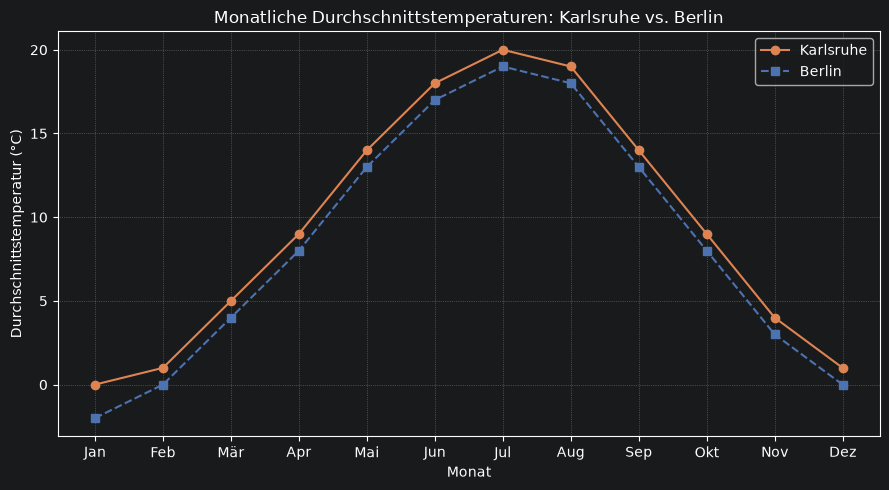

In [33]:
monate = ['Jan', 'Feb', 'Mär', 'Apr', 'Mai', 'Jun', 'Jul', 'Aug', 'Sep', 'Okt', 'Nov', 'Dez']
T_ka     = [0, 1, 5, 9, 14, 18, 20, 19, 14, 9, 4, 1]
T_berlin = [-2, 0, 4, 8, 13, 17, 19, 18, 13, 8, 3, 0]

# (b) Linienplot für beide Städte mit unterschiedlichen Farben und Linienstilen
plt.figure(figsize=(9, 5))
plt.plot(monate, T_ka,     color="#DD8452", linestyle="-",  marker="o", label="Karlsruhe")
plt.plot(monate, T_berlin, color="#4C72B0", linestyle="--", marker="s", label="Berlin")

# (c) Achsenbeschriftungen
plt.xlabel("Monat")
plt.ylabel("Durchschnittstemperatur (°C)")
plt.title("Monatliche Durchschnittstemperaturen: Karlsruhe vs. Berlin")

# (d) Legende
plt.legend()

plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# Übungsblatt 5

## Aufgabenstellung

**1 Beschreibung des Korpus**
- [X] Beschreiben Sie Ihren Korpus in Ihrer Ausarbeitung.
- [X] Aus wie vielen Word Types besteht Ihr Korpus?
- [X] Wie vielen Word Instances enthält Ihr Korpus?

**2 Wortfrequenzanalyse**
- [X] Wenden Sie die Tokenisierungsmethoden auf Ihren Datensatz an (Whitespace
und BPE).
- [X] Berechnen Sie die Häufigkeit der Word Types.
- [X] Visualisieren Sie die Wortfrequenzen in einem Barchart.
- [X] Ist das hilfreich zur Lösung Ihres Klassifikationsproblems?
- [X] Entfernen Sie Stop Words und führen Sie die Schritte oben erneut durch.
- [X] Welchen Einfluss hat die Vocabulary Size auf die häufigsten Token bei BPE..

**3 Vektorisierung**
Vektorisieren Sie Ihren Datensatz mit dem
- [X] Bag-of-Words Ansatz.
- [X] TF-IDF Ansatz.
- [X] N-gram Ansatz. Testen Sie verschiedene Werte für N.

Was fällt Ihnen auf?

### 1. Beschreibung des Korpus

Unser Korpus besteht aus Essay-Texten, die entweder von Studierenden verfasst (`generated=0`) oder von einem LLM generiert wurden (`generated=1`). Jeder Essay ist einem Schreibprompt (`prompt_id`) zugeordnet.

**Wichtige Begriffe:**
- **Word Type:** Ein eindeutiges Wort im Vokabular (z. B. "the" zählt nur einmal, egal wie oft es vorkommt)
- **Word Instance (Token):** Jedes Vorkommen eines Wortes im Text (z. B. "the" zählt jedes Mal)

In [4]:
print(f"Datensatz: {df.shape[0]} Zeilen, {df.shape[1]} Spalten")
print(f"Klassenverteilung:\n{df['generated'].value_counts()}")

Datensatz: 29145 Zeilen, 2 Spalten
Klassenverteilung:
generated
0    17508
1    11637
Name: count, dtype: int64


In [5]:
# Gesamten Korpus als einen langen String zusammenführen
corpus_text = " ".join(df["text"].tolist())
print(f"Gesamtlänge des Korpus: {len(corpus_text):,} Zeichen")
print(f"Anzahl Essays im Korpus: {len(df):,}")

Gesamtlänge des Korpus: 65,423,110 Zeichen
Anzahl Essays im Korpus: 29,145


In [6]:
# Einfache Whitespace-Tokenisierung für die Korpusbeschreibung
def whitespace_tokenize(text):
    return text.lower().split()

all_tokens = whitespace_tokenize(corpus_text)
word_types = set(all_tokens)

print(f"Word Instances (Tokens gesamt): {len(all_tokens):,}")
print(f"Word Types (eindeutige Wörter): {len(word_types):,}")
print(f"Type-Token-Ratio:               {len(word_types)/len(all_tokens):.4f}")

Word Instances (Tokens gesamt): 11,166,745
Word Types (eindeutige Wörter): 145,746
Type-Token-Ratio:               0.0131


**Interpretation der Type-Token-Ratio (TTR):**
Eine niedrige TTR bedeutet, dass im Korpus relativ wenige unterschiedliche Wörter sehr häufig wiederverwendet werden (typisch für natürliche Sprache, da Funktionswörter wie "the", "is" sehr häufig sind). [Eigene Beobachtung eintragen]

### 2. Wortfrequenzanalyse

#### 2a. Tokenisierungsmethoden anwenden

##### Methode 1: Whitespace-Tokenisierung

In [7]:
#### Methode 1: Whitespace-Tokenisierung
# Bereits oben angewendet – Wiederholung mit Beispieltext
sample_text = df["text"].iloc[0][:200]
ws_tokens = whitespace_tokenize(sample_text)

print("Beispieltext (Ausschnitt):")
print(sample_text)
print(f"\nWhitespace-Tokens (erste 20): {ws_tokens[:20]}")
print(f"Anzahl Tokens: {len(ws_tokens)}")

Beispieltext (Ausschnitt):
Car-free cities have become a subject of increasing interest and debate in recent years, as urban areas around the world grapple with the challenges of congestion, pollution, and limited resources. Th

Whitespace-Tokens (erste 20): ['car-free', 'cities', 'have', 'become', 'a', 'subject', 'of', 'increasing', 'interest', 'and', 'debate', 'in', 'recent', 'years,', 'as', 'urban', 'areas', 'around', 'the', 'world']
Anzahl Tokens: 31


##### Methode 2: BPE (Byte Pair Encoding)

BPE ist ein subword-basiertes Tokenisierungsverfahren: Häufige Zeichenfolgen werden iterativ zu größeren Einheiten zusammengeführt. Das ermöglicht die Zerlegung auch unbekannter Wörter in bekannte Subwort-Bausteine.

In [12]:
# BPE-Tokenizer trainieren (mit der tokenizers-Bibliothek von HuggingFace)
# Falls nicht installiert: !pip install tokenizers --quiet
def train_bpe_tokenizer(texts, vocab_size=5000):
    tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
    tokenizer.pre_tokenizer = Whitespace()
    trainer = BpeTrainer(vocab_size=vocab_size, special_tokens=["[UNK]"])
    tokenizer.train_from_iterator(texts, trainer=trainer)
    return tokenizer

# Trainieren auf einer Stichprobe des Korpus (Performance)
sample_corpus = df["text"].sample(2000, random_state=42).tolist()
bpe_tokenizer = train_bpe_tokenizer(sample_corpus, vocab_size=5000)

print(f"BPE-Vokabular trainiert mit {bpe_tokenizer.get_vocab_size()} Subwort-Einheiten")


BPE-Vokabular trainiert mit 5000 Subwort-Einheiten


In [13]:
# BPE auf den gleichen Beispieltext anwenden
bpe_output = bpe_tokenizer.encode(sample_text)
print("BPE-Tokens (erste 20):", bpe_output.tokens[:20])
print(f"Anzahl BPE-Tokens: {len(bpe_output.tokens)}")

BPE-Tokens (erste 20): ['Car', '-', 'free', 'cities', 'have', 'become', 'a', 'subject', 'of', 'increasing', 'interest', 'and', 'debate', 'in', 'recent', 'years', ',', 'as', 'urban', 'areas']
Anzahl BPE-Tokens: 39


**Vergleich Whitespace vs. BPE:**
- Whitespace zerlegt nur an Leerzeichen → ganze Wörter als Tokens.
- BPE kann Wörter in Subwort-Einheiten zerlegen (z. B. "tokenization" → "token" + "ization") → besser geeignet für unbekannte Wörter, Tippfehler oder seltene Begriffe.
[Eigene Beobachtung zum Beispieltext eintragen]


#### 2b. Häufigkeit der Word Types berechnen

In [14]:
# Wortfrequenzen über den gesamten Korpus (Whitespace-Tokenisierung)
word_freq = Counter(all_tokens)
most_common_20 = word_freq.most_common(20)

freq_df = pd.DataFrame(most_common_20, columns=["Wort", "Häufigkeit"])
freq_df


,Wort,Häufigkeit
0,the,531387
1,to,368634
2,and,285332
3,a,259420
4,of,257523
5,in,200953
6,is,174371
7,that,168977
8,for,124780
9,it,121786


#### 2c. Visualisierung: Wortfrequenzen (Barchart)

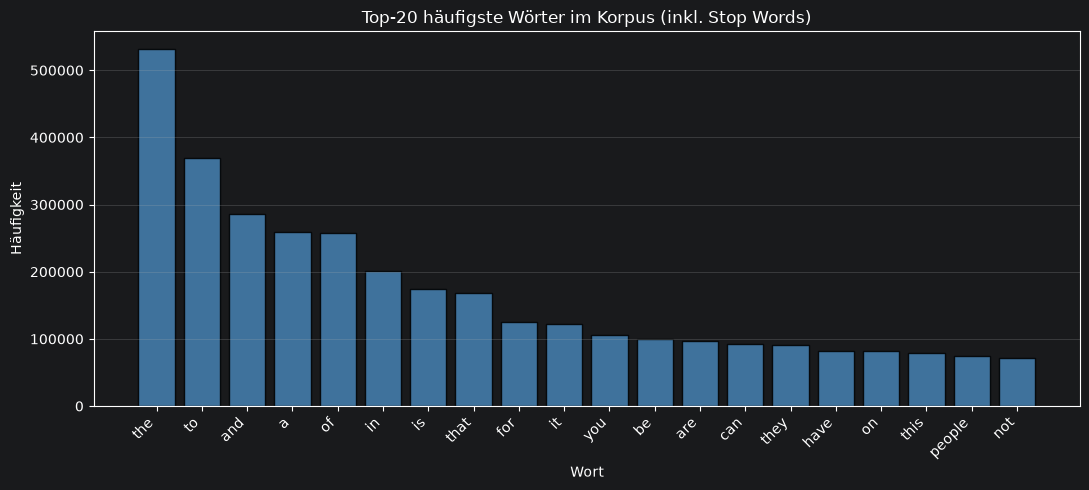

In [15]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(freq_df["Wort"], freq_df["Häufigkeit"], color="steelblue", edgecolor="black", alpha=0.85)
ax.set_xlabel("Wort")
ax.set_ylabel("Häufigkeit")
ax.set_title("Top-20 häufigste Wörter im Korpus (inkl. Stop Words)")
plt.xticks(rotation=45, ha="right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


**Ist das hilfreich zur Lösung des Klassifikationsproblems?**
Nein – die häufigsten Wörter sind fast ausschließlich Stop Words (z. B. "the", "and", "to"). Diese kommen in **beiden Klassen** (Mensch und KI) etwa gleich häufig vor und tragen daher kaum zur Unterscheidung bei. Für die Klassifikation sind seltenere, klassenspezifische Wörter meist aussagekräftiger.


#### 2d. Stop Words entfernen und Schritte wiederholen

In [17]:
# NLTK Stop Words laden
try:
    stop_words = set(stopwords.words("english"))
except LookupError:
    nltk.download("stopwords", quiet=True)
    stop_words = set(stopwords.words("english"))

print(f"Anzahl Stop Words (Englisch): {len(stop_words)}")
print(f"Beispiele: {list(stop_words)[:10]}")


Anzahl Stop Words (Englisch): 198
Beispiele: ["wasn't", 'ain', "he's", 'does', 'nor', 'once', 'm', "needn't", 'because', 'whom']


In [18]:
# Tokens ohne Stop Words (nur alphabetische Tokens)
filtered_tokens = [t for t in all_tokens if t.isalpha() and t not in stop_words]

word_freq_filtered = Counter(filtered_tokens)
most_common_20_filtered = word_freq_filtered.most_common(20)

freq_filtered_df = pd.DataFrame(most_common_20_filtered, columns=["Wort", "Häufigkeit"])
print(f"Word Instances ohne Stop Words: {len(filtered_tokens):,}")
print(f"Word Types ohne Stop Words:     {len(set(filtered_tokens)):,}")
freq_filtered_df

Word Instances ohne Stop Words: 4,788,645
Word Types ohne Stop Words:     62,807


,Wort,Häufigkeit
0,people,74071
1,electoral,43226
2,would,41699
3,one,35121
4,also,33059
5,car,32895
6,college,30419
7,could,29835
8,like,29490
9,many,28968


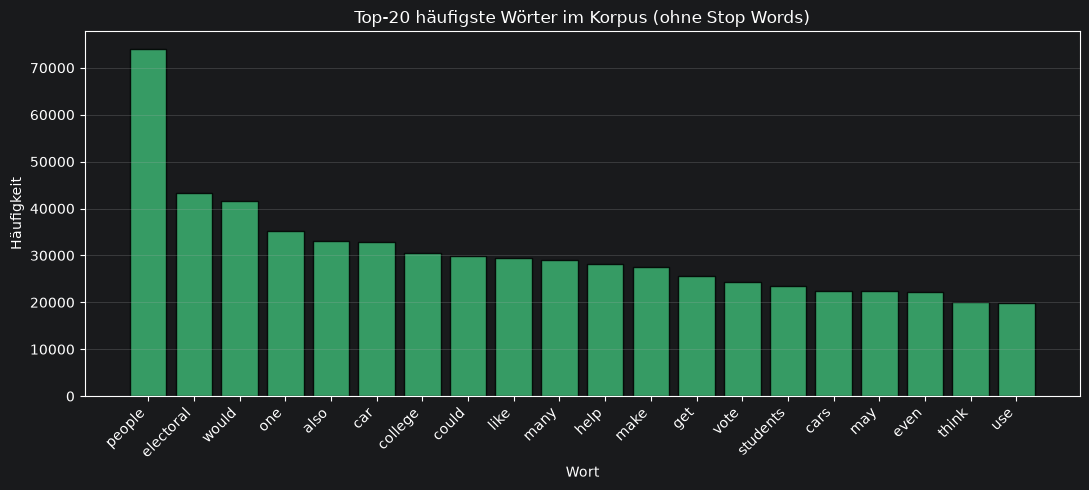

In [19]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(freq_filtered_df["Wort"], freq_filtered_df["Häufigkeit"], color="mediumseagreen", edgecolor="black", alpha=0.85)
ax.set_xlabel("Wort")
ax.set_ylabel("Häufigkeit")
ax.set_title("Top-20 häufigste Wörter im Korpus (ohne Stop Words)")
plt.xticks(rotation=45, ha="right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Beobachtung nach Entfernung der Stop Words:**
Die verbleibenden häufigsten Wörter sind inhaltstragender (z. B. thematische Begriffe aus den Essay-Prompts). Diese Wörter sind potenziell aussagekräftiger für die Klassifikation, da sie inhaltliche statt grammatische Muster widerspiegeln.
[Eigene Beobachtung eintragen – welche Wörter dominieren jetzt? Ergeben sie inhaltlich Sinn für die Prompt-Themen?]

#### 2e. Einfluss der Vocabulary Size auf BPE

In [20]:
# BPE mit unterschiedlichen Vocabulary Sizes trainieren und Top-Tokens vergleichen
vocab_sizes = [500, 2000, 5000, 10000]
bpe_results = {}

for vsize in vocab_sizes:
    tok = train_bpe_tokenizer(sample_corpus, vocab_size=vsize)
    vocab = tok.get_vocab()
    # Häufigste Tokens im Beispieltext mit diesem Vokabular
    encoded = tok.encode(sample_text)
    bpe_results[vsize] = encoded.tokens

for vsize, tokens in bpe_results.items():
    print(f"Vocab Size = {vsize:>6} | Anzahl Tokens im Beispieltext: {len(tokens):>3} | Erste Tokens: {tokens[:10]}")

Vocab Size =    500 | Anzahl Tokens im Beispieltext:  76 | Erste Tokens: ['C', 'ar', '-', 'f', 'ree', 'c', 'ities', 'have', 'be', 'come']
Vocab Size =   2000 | Anzahl Tokens im Beispieltext:  43 | Erste Tokens: ['Car', '-', 'free', 'cities', 'have', 'become', 'a', 'subject', 'of', 'increasing']
Vocab Size =   5000 | Anzahl Tokens im Beispieltext:  39 | Erste Tokens: ['Car', '-', 'free', 'cities', 'have', 'become', 'a', 'subject', 'of', 'increasing']
Vocab Size =  10000 | Anzahl Tokens im Beispieltext:  39 | Erste Tokens: ['Car', '-', 'free', 'cities', 'have', 'become', 'a', 'subject', 'of', 'increasing']


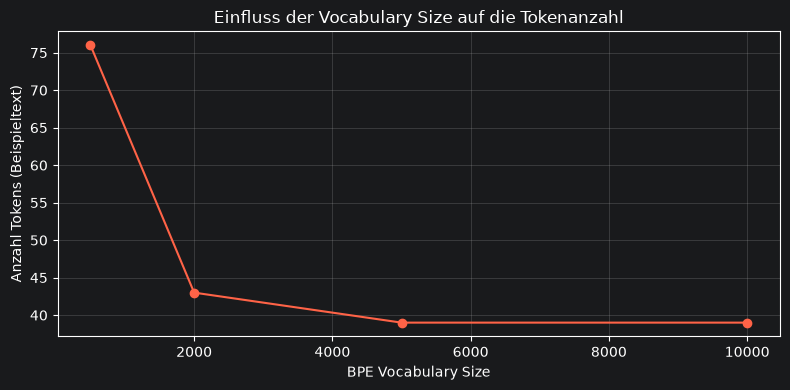

In [21]:
# Visualisierung: Anzahl Tokens im Beispieltext je Vocabulary Size
token_counts = [len(tokens) for tokens in bpe_results.values()]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(vocab_sizes, token_counts, marker="o", color="tomato")
ax.set_xlabel("BPE Vocabulary Size")
ax.set_ylabel("Anzahl Tokens (Beispieltext)")
ax.set_title("Einfluss der Vocabulary Size auf die Tokenanzahl")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Beobachtung:**
Mit **steigender Vocabulary Size** kann BPE mehr ganze Wörter direkt als ein einzelnes Token abbilden, statt sie in mehrere Subwort-Einheiten zu zerlegen → die Tokenanzahl für denselben Text **sinkt**. Bei einer **kleinen Vocabulary Size** werden Wörter stärker in kleinere Subwort-Bausteine zerlegt → mehr Tokens pro Text, aber kompakteres Vokabular insgesamt.
[Eigene Beobachtung eintragen]

### 3. Vektorisierung

Im Folgenden vergleichen wir drei klassische Ansätze, um Texte in numerische Vektoren umzuwandeln, die ein ML-Modell verarbeiten kann.

In [22]:
# Train/Test Split für die Vektorisierungs-Experimente
X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["generated"], test_size=0.2, random_state=42, stratify=df["generated"]
)
print(f"Trainingsdaten: {len(X_train)} | Testdaten: {len(X_test)}")


Trainingsdaten: 23316 | Testdaten: 5829


#### 3a. Bag-of-Words (BoW)

In [23]:
bow_vectorizer = CountVectorizer(max_features=5000, stop_words="english")
X_train_bow = bow_vectorizer.fit_transform(X_train)

print(f"BoW Feature-Matrix Shape: {X_train_bow.shape}")
print(f"Beispiel-Vokabular (10 Wörter): {bow_vectorizer.get_feature_names_out()[:10]}")
print(f"\nSparsity (Anteil Nullen): {1 - X_train_bow.nnz / (X_train_bow.shape[0]*X_train_bow.shape[1]):.4f}")

BoW Feature-Matrix Shape: (23316, 5000)
Beispiel-Vokabular (10 Wörter): ['00' '000' '10' '100' '11' '114' '118' '12' '13' '14']

Sparsity (Anteil Nullen): 0.9795


**Eigenschaften von Bag-of-Words:**
- Zählt nur, *wie oft* ein Wort vorkommt – ignoriert Wortreihenfolge und Kontext.
- Sehr einfach und schnell zu berechnen.
- Häufige Wörter dominieren den Vektor (auch ohne inhaltliche Relevanz).


#### 3b. TF-IDF

In [24]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words="english", sublinear_tf=True)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

print(f"TF-IDF Feature-Matrix Shape: {X_train_tfidf.shape}")

# Vergleich der Gewichtung eines Beispielworts
sample_word_idx = list(tfidf_vectorizer.vocabulary_.values())[0]
sample_word = tfidf_vectorizer.get_feature_names_out()[sample_word_idx]
print(f"\nBeispiel-Feature: '{sample_word}'")
print(f"  BoW-Wert (Dokument 0):   {X_train_bow[0, sample_word_idx]}")
print(f"  TF-IDF-Wert (Dokument 0): {X_train_tfidf[0, sample_word_idx]:.4f}")

TF-IDF Feature-Matrix Shape: (23316, 5000)

Beispiel-Feature: 'essay'
  BoW-Wert (Dokument 0):   1
  TF-IDF-Wert (Dokument 0): 0.1068


**Eigenschaften von TF-IDF:**
- Gewichtet Wörter danach, wie **selten** sie im Gesamtkorpus sind (Inverse Document Frequency).
- Wörter, die in vielen Dokumenten vorkommen (z. B. "essay", "people"), erhalten ein niedrigeres Gewicht.
- Seltene, aber in einem Dokument häufige Wörter erhalten ein höheres Gewicht → meist aussagekräftiger als BoW.

#### 3c. N-Gram Ansatz – verschiedene N-Werte testen

In [25]:
ngram_ranges = [(1, 1), (1, 2), (1, 3), (2, 2)]
ngram_results = []

for ngram_range in ngram_ranges:
    vec = TfidfVectorizer(max_features=5000, stop_words="english",
                          ngram_range=ngram_range, sublinear_tf=True)
    X_ngram = vec.fit_transform(X_train)

    ngram_results.append({
        "N-Gram Range": str(ngram_range),
        "Vokabulargröße": len(vec.vocabulary_),
        "Beispiel-Features": ", ".join(vec.get_feature_names_out()[-5:])
    })

ngram_df = pd.DataFrame(ngram_results)
ngram_df

,N-Gram Range,Vokabulargröße,Beispiel-Features
0,"(1, 1)",5000,"zero, zip, zone, zones, zygomatic"
1,"(1, 2)",5000,"younger students, youth, zip, zone, zones"
2,"(1, 3)",5000,"younger people, younger students, youth, zip, ..."
3,"(2, 2)",5000,"younger people, younger students, zip code, zi..."


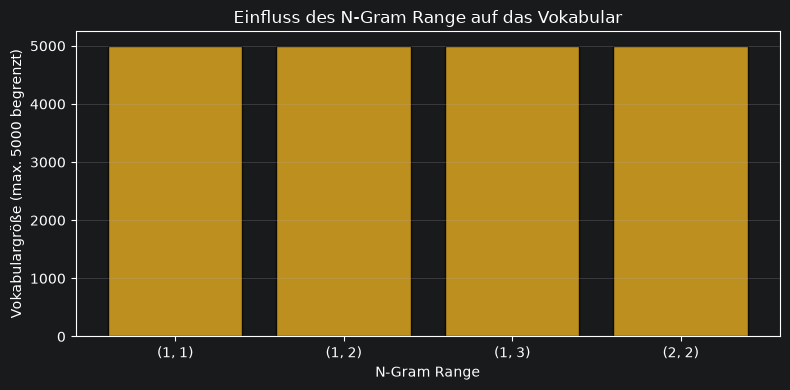

In [34]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(ngram_df["N-Gram Range"], ngram_df["Vokabulargröße"], color="goldenrod", edgecolor="black", alpha=0.85)
ax.set_xlabel("N-Gram Range")
ax.set_ylabel("Vokabulargröße (max. 5000 begrenzt)")
ax.set_title("Einfluss des N-Gram Range auf das Vokabular")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Was fällt auf?**
- **Unigrams (1,1):** Einzelne Wörter – kompaktes Vokabular, aber kein Kontext.
- **Bigrams/Trigrams (1,2), (1,3):** Erfassen Wortkombinationen (z. B. "I think", "in conclusion") – können stilistische Muster abbilden, die für KI- vs. Menschtexte typisch sind (z. B. typische LLM-Phrasen).
- **Reine Bigrams (2,2):** Verlieren einzelne Wörter komplett, was oft zu Informationsverlust führt.
- Mit steigendem N wächst die Anzahl möglicher Kombinationen exponentiell – bei fixiertem `max_features` werden daher viele seltene Wortkombinationen nicht mehr abgedeckt.

[Eigene Beobachtung eintragen: Welcher N-Gram-Bereich erscheint für die KI-Text-Erkennung am vielversprechendsten?]

### Fazit

##### Zusammenfassung der Erkenntnisse

| Aspekt | Erkenntnis |
|--------|-----------|
| Word Types / Instances | [eigene Werte eintragen] |
| Whitespace vs. BPE | BPE zerlegt in Subwörter, robuster bei seltenen/unbekannten Wörtern |
| Stop Words | Ohne Entfernung dominieren Funktionswörter – wenig hilfreich für Klassifikation |
| BPE Vocabulary Size | Größeres Vokabular → weniger, aber größere Tokens pro Text |
| BoW vs. TF-IDF | TF-IDF gewichtet seltene, aussagekräftige Wörter stärker |
| N-Gramme | Höhere N erfassen Phrasenmuster, aber Vokabular wächst stark |

##### Empfehlung für das Klassifikationsproblem

[Eigene Einschätzung: Welche Vektorisierungsmethode erscheint am geeignetsten für die KI-Texterkennung, und warum?]

# Übungsblatt 6

## Aufgabenstellung

**1 Input- und Output Variablen**
- [X] Welche sind die Input- und Output Variablen in dem von Ihnen gewählten Datensatz?
- [X] Dokumentieren Sie im Jupyter Notebook.

**2 Prediction vs. Inference**
- [X] Formulieren Sie für Ihren Datensatz eine Fragestellung für Prediction und Inference.
- [X] Dokumentieren Sie im Juypter Notebook.

**3 Klassifikation vs. Regression**
- [X] Welches Machine Learning Problem können Sie anhand Ihres Datensatzes angehen: Regression oder Klassifikation?
- [X] Dokumentieren Sie im Juypter Notebook.

### 1 Input- und Output Variablen

#### Überblick der Variablen

| Variable | Typ | Rolle | Begründung |
|----------|-----|-------|------------|
| `text` | Freitext (String) | **Input (Feature)** | Der Essay-Text ist die einzige Informationsquelle für die Klassifikation |
| `prompt_id` | Nominal (Integer) | Input (optional) | Kann als zusätzliches Merkmal genutzt werden |
| `id` | Nominal (Integer) | Kein Feature | Reiner Identifier, keine inhaltliche Information |
| `generated` | Binär (0/1) | **Output (Zielvariable)** | Das Modell soll vorhersagen, ob ein Text KI-generiert ist |

#### Input-Variable: `text`

Da Modelle nicht direkt mit Rohtexten arbeiten können, wird `text` in numerische Features umgewandelt:
- **TF-IDF Vektorisierung** (klassisch, gut für Baseline-Modelle)
- **Wort-Embeddings** (Word2Vec, GloVe – für fortgeschrittene Modelle)
- **Feature Engineering** (Textlänge, Satzanzahl, Wortvielfalt, etc.)

In [24]:
# Input-Variable: Text-Features ableiten (Feature Engineering)
df["text_length"]    = df["text"].str.len()
df["word_count"]     = df["text"].str.split().str.len()
df["sentence_count"] = df["text"].str.split(r'[.!?]+').str.len()
df["avg_word_length"] = df["text"].apply(
    lambda t: sum(len(w) for w in t.split()) / max(len(t.split()), 1)
)

print("Abgeleitete Features:")
df[["text_length", "word_count", "sentence_count", "avg_word_length", "generated"]].describe()

Abgeleitete Features:


,text_length,word_count,sentence_count,avg_word_length,generated
count,27340.000000,27340.00000,27340.000000,27340.000000,27340.000000
mean,2184.125347,373.27297,19.473555,4.834367,0.410315
std,970.325959,168.66025,9.636291,0.520616,0.491900
min,1.000000,1.00000,1.000000,1.000000,0.000000
25%,1470.000000,255.00000,12.000000,4.452446,0.000000
50%,2105.000000,345.00000,18.000000,4.743407,0.000000
75%,2656.000000,459.00000,25.000000,5.180682,1.000000
max,9169.000000,1650.00000,110.000000,6.869186,1.000000


In [25]:
# Output-Variable: Verteilung
print("Verteilung der Zielvariable 'generated':")
print(df["generated"].value_counts())
print(f"\n0 = menschlich geschrieben\n1 = KI-generiert")

Verteilung der Zielvariable 'generated':
generated
0    16122
1    11218
Name: count, dtype: int64

0 = menschlich geschrieben
1 = KI-generiert


### 2 Prediction vs. Inference

#### Prediction (Vorhersage)

> **Fragestellung:** *Gegeben einen neuen, unbekannten Essay-Text – wurde er von einem Menschen oder einer KI geschrieben?*

- Ziel: Möglichst genaue Vorhersage der Klasse `generated` für neue, ungesehene Texte
- Die Interpretierbarkeit des Modells ist zweitrangig
- Geeignete Modelle: Random Forest, Gradient Boosting, neuronale Netze

#### Inference (Analyse / Schlussfolgern)

> **Fragestellung:** *Welche sprachlichen Merkmale eines Textes sind charakteristisch für KI-generierte Essays? Hat z. B. die Textlänge oder der Wortschatz einen signifikanten Einfluss auf die Klassenzugehörigkeit?*

- Ziel: Verstehen, *warum* ein Text als KI-generiert eingestuft wird
- Interpretierbarkeit des Modells ist wichtig
- Geeignete Modelle: Logistic Regression, Decision Tree (mit Feature Importance)

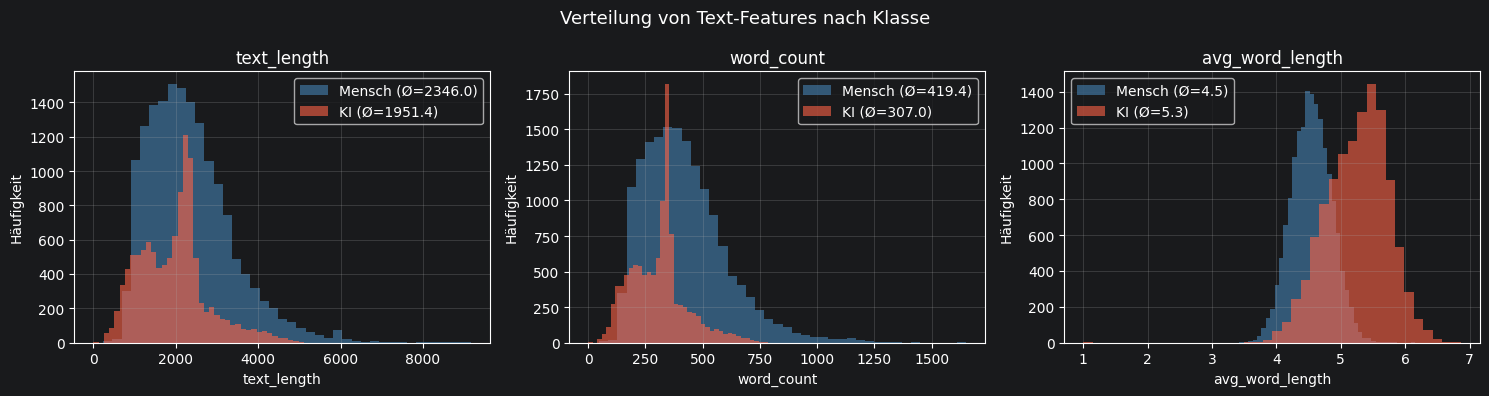

In [26]:
# Inference-Beispiel: Unterscheiden sich KI- und menschliche Texte in messbaren Merkmalen?
features = ["text_length", "word_count", "avg_word_length"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feat in zip(axes, features):
    for label, color in [(0, "steelblue"), (1, "tomato")]:
        subset = df[df["generated"] == label][feat]
        ax.hist(subset, bins=40, alpha=0.6, color=color,
                label=f"{'Mensch' if label==0 else 'KI'} (Ø={subset.mean():.1f})")
    ax.set_title(feat)
    ax.set_xlabel(feat)
    ax.set_ylabel("Häufigkeit")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("Verteilung von Text-Features nach Klasse", fontsize=13)
plt.tight_layout()
plt.show()

**Erkenntnis:**
- Die `text_length` der menschlichen Texte ist in der Regel deutlich höher, als die der KI-generierten Texte.
- Die menschlichen Texte haben hauptsächlich einen `word_count` zwischen ca. 200 und 550. Die KI-generierten Texte haben jedoch auffälligerweise eine sehr große Häufigkeit von einem `word_count` von ca. 350.
- KI-genrierte Texte haben im Durchschnitt eine höhere `avg_word_length` als menschliche Texte.

### 3 Klassifikation vs. Regression

#### Entscheidung: **Klassifikation**

Die Zielvariable `generated` ist **binär** (0 oder 1) – es gibt genau zwei diskrete Klassen:
- Klasse 0: Essay wurde von einem **Menschen** verfasst
- Klasse 1: Essay wurde von einer **KI** (LLM) generiert

Dies ist ein typisches **binäres Klassifikationsproblem**.

**Warum kein Regressionsproblem?**
Regression würde einen kontinuierlichen Ausgabewert vorhersagen (z. B. einen Preis oder eine Temperatur). Hier ist der Output diskret und kategorial, daher ist Klassifikation die passende Methode.

**Geeignete Klassifikationsmodelle:**
- Logistic Regression (gute Baseline, gut interpretierbar)
- Naive Bayes (besonders für Textdaten geeignet)
- Random Forest / Gradient Boosting
- Support Vector Machine (SVM)

In [27]:
# Zusammenfassung
summary = {
    "Input-Variablen": ["text (Hauptfeature), prompt_id (optional)"],
    "Output-Variable": ["generated (0=Mensch, 1=KI)"],
    "Prediction-Frage": ["Ist ein neuer Essay KI-generiert?"],
    "Inference-Frage": ["Welche Textmerkmale sind typisch für KI-Texte?"],
    "ML-Problem": ["Binäre Klassifikation"],
}

for key, val in summary.items():
    print(f"{key:25s}: {val[0]}")

Input-Variablen          : text (Hauptfeature), prompt_id (optional)
Output-Variable          : generated (0=Mensch, 1=KI)
Prediction-Frage         : Ist ein neuer Essay KI-generiert?
Inference-Frage          : Welche Textmerkmale sind typisch für KI-Texte?
ML-Problem               : Binäre Klassifikation


# Übungsblatt 7

## Aufgabenstellung

**1 Training und Test von Modellen**

Verwenden Sie die in der Vorlesung besprochenen Klassifikationsmodelle und finden
Sie das Modell mit der höchsten Vorhersagegenauigkeit bzw. dem kleinsten Fehler
(wählen Sie geeignete Metriken). Vergleichen Sie verschiedene Modelltypen. Variieren
Sie Parameter je Modelltyp.
- [X] Teilen Sie den Datensatz in Trainings-, Validierungs- und Testdaten auf. Ver-
wenden Sie Testdaten nicht für Modellentscheidungen.
- [X] Trainieren Sie Modelle basierend auf den Trainingsdaten.
- [X] Vergleichen Sie basierend auf einer passenden Metrik.
- [X] Wählen Sie das beste Modell und testen Sie es, basierend auf bisher ungesehenen
Testdaten.
- [X] Prüfen Sie eine Stichprobe bzgl. Modellvorhersage und echtem Wert.
- [X] Vergleichen Sie verschiedene Modelle bzgl. Trainings- und Validierungsmetrik,
erstellen Sie eine Grafik.
- [X] Dokumentieren Sie die Erkenntnisse und bewerten Sie die Ergebnisse kritisch.
Womit haben Sie gerechnet, was hat Sie überrascht.

### K-Nearest Neighbors

#### Theoretischer Hintergrund

**K-Nearest Neighbors (KNN)** ist ein instanzbasierter Lernalgorithmus ohne explizite Trainingsphase:
- Zur Klassifikation eines neuen Datenpunkts werden die **k nächsten Nachbarn** im Feature-Raum gesucht.
- Die Klasse wird per **Mehrheitsvotum** der k Nachbarn bestimmt.
- Die Distanz wird typischerweise mit der **euklidischen Distanz** gemessen.
- **Hyperparameter k**: Klein → hohes Overfitting-Risiko; Groß → Glattere Entscheidungsgrenze, aber ggf. Underfitting.

> **Hinweis für diesen Datensatz:** KNN auf rohem TF-IDF ist sehr rechenintensiv (10.000-dimensionaler Raum). Wir reduzieren die Dimensionen mit **TruncatedSVD (LSA)** und begrenzen die Datenmenge für schnelle Ausführung.

#### Train / Validation / Test Split

Der Datensatz wird in drei Teile aufgeteilt:
- **Trainingsdaten (60 %)**: Zum Trainieren der Modelle
- **Validierungsdaten (20 %)**: Zur Modellauswahl und Hyperparameter-Tuning
- **Testdaten (20 %)**: Nur für die finale Evaluation des besten Modells

**Wichtig:** Testdaten werden erst ganz am Ende verwendet!

In [28]:
X = df["text"]
y = df["generated"]

# Erst Train+Val / Test aufteilen
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# Dann Train / Validation aufteilen
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval
)

print(f"Trainingsdaten:    {len(X_train):>5} Samples ({len(X_train)/len(X)*100:.0f}%)")
print(f"Validierungsdaten: {len(X_val):>5} Samples ({len(X_val)/len(X)*100:.0f}%)")
print(f"Testdaten:         {len(X_test):>5} Samples ({len(X_test)/len(X)*100:.0f}%)")


Trainingsdaten:    16404 Samples (60%)
Validierungsdaten:  5468 Samples (20%)
Testdaten:          5468 Samples (20%)


#### Feature Extraction – TF-IDF  + Dimensionsreduktion (LSA)

KNN berechnet Abstände zwischen allen Punkten – im 10.000-dimensionalen TF-IDF-Raum ist das sehr langsam.
Lösung: **Truncated SVD** (= Latent Semantic Analysis) reduziert die Dimensionen auf 100, ohne wesentliche Information zu verlieren.

In [31]:
# TF-IDF → Dimensionsreduktion auf 100 Komponenten → Normalisierung
tfidf = TfidfVectorizer(max_features=5000, sublinear_tf=True)
svd   = TruncatedSVD(n_components=100, random_state=42)
norm  = Normalizer(copy=False)

# Fit nur auf Trainingsdaten!
X_train_tfidf = tfidf.fit_transform(X_train)
X_train_svd   = svd.fit_transform(X_train_tfidf)
X_train_norm  = norm.fit_transform(X_train_svd)

X_val_norm    = norm.transform(svd.transform(tfidf.transform(X_val)))
X_test_norm   = norm.transform(svd.transform(tfidf.transform(X_test)))

print(f"Shape nach TF-IDF:  {X_train_tfidf.shape}")
print(f"Shape nach SVD:     {X_train_svd.shape}")
print(f"Erklärte Varianz durch SVD: {svd.explained_variance_ratio_.sum()*100:.1f}%")

Shape nach TF-IDF:  (16404, 5000)
Shape nach SVD:     (16404, 100)
Erklärte Varianz durch SVD: 28.7%


#### Modell trainieren & Hyperparameter k vergleichen

Wir testen verschiedene Werte für k, um den optimalen Parameter zu finden.

In [32]:
k_values = [1, 3, 5, 7, 10, 15, 20, 30]
results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean", n_jobs=-1)
    knn.fit(X_train_norm, y_train)

    train_acc = accuracy_score(y_train, knn.predict(X_train_norm))
    val_acc   = accuracy_score(y_val,   knn.predict(X_val_norm))

    results.append({"k": k, "Train Accuracy": round(train_acc, 4), "Val Accuracy": round(val_acc, 4)})
    print(f"k={k:>2} | Train: {train_acc:.4f} | Val: {val_acc:.4f}")

results_df = pd.DataFrame(results)
results_df


k= 1 | Train: 1.0000 | Val: 0.9932
k= 3 | Train: 0.9971 | Val: 0.9941
k= 5 | Train: 0.9962 | Val: 0.9936
k= 7 | Train: 0.9957 | Val: 0.9940
k=10 | Train: 0.9945 | Val: 0.9918
k=15 | Train: 0.9941 | Val: 0.9916
k=20 | Train: 0.9926 | Val: 0.9909
k=30 | Train: 0.9899 | Val: 0.9892


,k,Train Accuracy,Val Accuracy
0,1,1.0000,0.9932
1,3,0.9971,0.9941
2,5,0.9962,0.9936
3,7,0.9957,0.9940
4,10,0.9945,0.9918
5,15,0.9941,0.9916
6,20,0.9926,0.9909
7,30,0.9899,0.9892


#### Visualisierung – Einfluss von k auf die Accuracy

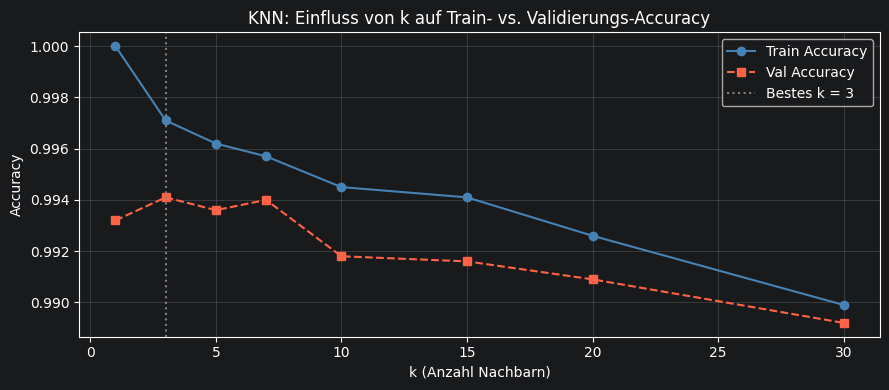


Bestes k (nach Val Accuracy): k = 3


In [33]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(results_df["k"], results_df["Train Accuracy"], marker="o", label="Train Accuracy", color="steelblue")
ax.plot(results_df["k"], results_df["Val Accuracy"],   marker="s", label="Val Accuracy",   color="tomato", linestyle="--")

best_k = results_df.loc[results_df["Val Accuracy"].idxmax(), "k"]
ax.axvline(x=best_k, color="gray", linestyle=":", label=f"Bestes k = {best_k}")

ax.set_xlabel("k (Anzahl Nachbarn)")
ax.set_ylabel("Accuracy")
ax.set_title("KNN: Einfluss von k auf Train- vs. Validierungs-Accuracy")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nBestes k (nach Val Accuracy): k = {best_k}")

**Beobachtung:**
- Bei **kleinem k** (z.B. k=1) ist der Train-Accuracy sehr hoch → starkes Overfitting.
- Mit wachsendem k sinkt der Train-Val-Gap → das Modell generalisiert besser.
- Ab einem bestimmten k sinkt auch die Val-Accuracy wieder → Underfitting.

→ Das am besten geeignete k ist 3, da hier höchste Train Accuracy in Kombination mit einer hohen Val Accuracy auftritt.

#### Bestes Modell auf Testdaten evaluieren

In [34]:
# Bestes k auswählen
best_k = results_df.loc[results_df["Val Accuracy"].idxmax(), "k"]
print(f"Gewähltes k: {best_k}")

# Finales Modell trainieren und auf Testdaten anwenden
knn_best = KNeighborsClassifier(n_neighbors=best_k, metric="euclidean", n_jobs=-1)
knn_best.fit(X_train_norm, y_train)

y_pred_test = knn_best.predict(X_test_norm)
test_acc    = accuracy_score(y_test, y_pred_test)

print(f"Test Accuracy: {test_acc:.4f}")
print("\nKlassifikationsbericht:")
print(classification_report(y_test, y_pred_test, target_names=["Mensch (0)", "KI (1)"]))

Gewähltes k: 3
Test Accuracy: 0.9936

Klassifikationsbericht:
              precision    recall  f1-score   support

  Mensch (0)       0.99      1.00      0.99      3224
      KI (1)       0.99      0.99      0.99      2244

    accuracy                           0.99      5468
   macro avg       0.99      0.99      0.99      5468
weighted avg       0.99      0.99      0.99      5468



Wir erstellen nun eine Konfusionsmatrix.

Eine Konfusionsmatrix ist eine Tabelle, die zeigt, wie gut ein Klassifikationsmodell
funktioniert – und zwar nicht nur ob es richtig oder falsch liegt, sondern **wo genau**
es Fehler macht.

##### Aufbau (am Beispiel: Mensch vs. KI)

|  | **Vorhergesagt: Mensch** | **Vorhergesagt: KI** |
|---|---|---|
| **Tatsächlich: Mensch** | True Negative (TN) | False Positive (FP) |
| **Tatsächlich: KI** | False Negative (FN) | True Positive (TP) |

- **True Positive (TP):** Modell sagt KI → ist tatsächlich KI
- **True Negative (TN):** Modell sagt Mensch → ist tatsächlich Mensch
- **False Positive (FP):** Modell sagt KI → ist aber ein Mensch (Falschalarm)
- **False Negative (FN):** Modell sagt Mensch → ist aber KI (übersehen)

##### Metriken aus der Konfusionsmatrix

| Metrik | Formel | Bedeutung |
|--------|--------|-----------|
| **Accuracy** | (TP + TN) / alle | Gesamtanteil korrekt |
| **Precision** | TP / (TP + FP) | Von allen als KI eingestuften: wie viele waren wirklich KI? |
| **Recall** | TP / (TP + FN) | Von allen echten KI-Texten: wie viele hat das Modell erkannt? |
| **F1-Score** | 2 × (Precision × Recall) / (Precision + Recall) | Harmonisches Mittel – sinnvoll bei ungleichen Klassen |

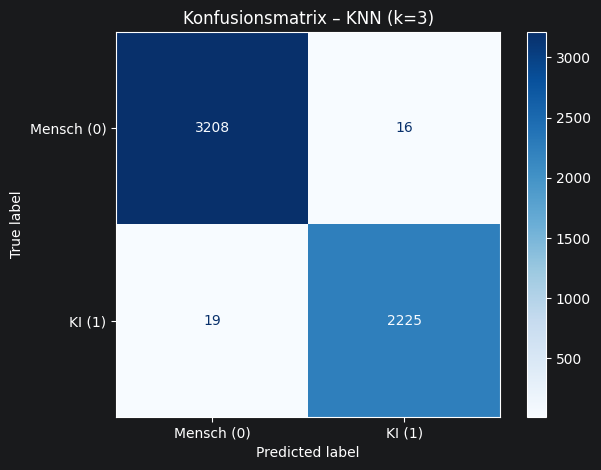

In [35]:
# Konfusionsmatrix
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Mensch (0)", "KI (1)"])
disp.plot(cmap="Blues")
plt.title(f"Konfusionsmatrix – KNN (k={best_k})")
plt.tight_layout()
plt.show()

#### Stichprobe: Vorhersage vs. echtem Wert

In [36]:
sample_idx   = X_test.sample(10, random_state=7).index
sample_texts = X_test.loc[sample_idx]
sample_true  = y_test.loc[sample_idx]
sample_norm  = norm.transform(svd.transform(tfidf.transform(sample_texts)))
sample_pred  = knn_best.predict(sample_norm)

pd.DataFrame({
    "Text (Ausschnitt)": [t[:80] + "..." for t in sample_texts],
    "Wahrer Wert":       sample_true.values,
    "Vorhersage":        sample_pred,
    "Korrekt?":          ["ja" if t==p else "nein" for t, p in zip(sample_true.values, sample_pred)]
})


,Text (Ausschnitt),Wahrer Wert,Vorhersage,Korrekt?
0,"From saving money to having less polution, lim...",0,0,ja
1,Not too long ago I got into a disagreement wit...,0,0,ja
2,This painting is was made a long time ago. Man...,0,0,ja
3,The concept of free will has been a topic of d...,1,1,ja
4,In today's society cell phones and technology ...,0,0,ja
5,"The face on Mars was not made by aliens, and i...",0,0,ja
6,I say we should keep the Electoral collage. Th...,0,0,ja
7,"Dear Senator,\r\n\r\nI am writing to express m...",1,1,ja
8,"The world is advancing, technologies are being...",0,0,ja
9,Why would seeking multiple opinions about advi...,0,0,ja


#### Erkenntnisse & Bewertung

##### Zusammenfassung

| Bestes k | Val Accuracy | Test Accuracy |
|----------|-------------|---------------|
| [eintragen] | [eintragen] | [eintragen] |

##### Stärken von KNN

- Kein explizites Training nötig (lazy learner)
- Einfach zu verstehen und zu implementieren
- Nicht-lineare Entscheidungsgrenzen möglich

##### Schwächen von KNN

- Sehr langsam bei großen Datensätzen (muss alle Distanzen berechnen)
- Sensitiv gegenüber irrelevanten Features und hoher Dimensionalität (Fluch der Dimensionalität)
- Dimensionsreduktion notwendig für Textdaten

##### Was haben wir erwartet / Was hat überrascht?

[Eigene Reflexion der Gruppe eintragen]

### Cross-Validation

#### Theoretischer Hintergrund

**Cross-Validation (Kreuzvalidierung)** ist keine eigene Modellklasse, sondern eine **Evaluierungsmethode**, die robustere Schätzungen der Modellgüte liefert als ein einfacher Train/Val-Split.

**k-Fold Cross-Validation:**
1. Der Datensatz wird in **k gleich große Teile (Folds)** aufgeteilt.
2. Das Modell wird **k-mal** trainiert – jedes Mal ist ein anderes Fold das Validierungsset, der Rest ist Trainingsdaten.
3. Die k Ergebnisse werden gemittelt → stabilere Schätzung, weniger abhängig vom Zufall des Splits.

**Vorteile gegenüber einfachem Train/Val-Split:**
- Jedes Sample wird genau einmal zur Validierung verwendet
- Geringere Varianz der Schätzung
- Besonders nützlich bei kleineren Datensätzen

> In diesem Notebook wenden wir k-Fold Cross-Validation auf mehrere Klassifikationsmodelle an und vergleichen ihre CV-Scores.

#### Train / Test Split

Bei Cross-Validation brauchen wir nur einen Train/Test-Split – die Validierung übernimmt das k-Fold-Verfahren automatisch.

In [37]:
X = df["text"]
y = df["generated"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Trainingsdaten (für CV): {len(X_train)} Samples")
print(f"Testdaten (zurückgehalten): {len(X_test)} Samples")


Trainingsdaten (für CV): 21872 Samples
Testdaten (zurückgehalten): 5468 Samples


#### Feature-Pipeline aufbauen

Damit kein Data Leakage entsteht, muss der TF-IDF-Vectorizer **innerhalb** jedes CV-Folds gefittet werden. Das erreichen wir mit einer **sklearn Pipeline**.

In [38]:
# Pipelines: TF-IDF + Modell in einem Objekt
# So wird der Vectorizer bei jeder CV-Iteration nur auf den Trainingsteil gefittet

pipelines = {
    "Logistic Regression": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=10000, sublinear_tf=True)),
        ("clf",   LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Naive Bayes": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=10000, sublinear_tf=True)),
        ("clf",   MultinomialNB())
    ]),
    "Linear SVM": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=10000, sublinear_tf=True)),
        ("clf",   LinearSVC(max_iter=2000, random_state=42))
    ]),
    "Decision Tree": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000, sublinear_tf=True)),
        ("clf",   DecisionTreeClassifier(max_depth=10, random_state=42))
    ]),
}

print("Pipelines definiert:")
for name in pipelines:
    print(f"  • {name}")


Pipelines definiert:
  • Logistic Regression
  • Naive Bayes
  • Linear SVM
  • Decision Tree


#### k-Fold Cross-Validation durchführen

Wir verwenden **Stratified k-Fold** (k=5), das die Klassenverteilung in jedem Fold beibehält – wichtig bei potenziell unausgeglichenen Klassen.

In [39]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, pipeline in pipelines.items():
    scores = cross_val_score(pipeline, X_train, y_train,
                             cv=cv_strategy, scoring="accuracy", n_jobs=-1)
    cv_results.append({
        "Modell":        name,
        "CV Mean Acc":   round(scores.mean(), 4),
        "CV Std Acc":    round(scores.std(), 4),
        "Fold Scores":   [round(s, 4) for s in scores],
    })
    print(f"{name:25s} | CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

cv_df = pd.DataFrame(cv_results).sort_values("CV Mean Acc", ascending=False)
cv_df[["Modell", "CV Mean Acc", "CV Std Acc", "Fold Scores"]]


Logistic Regression       | CV Accuracy: 0.9892 ± 0.0003
Naive Bayes               | CV Accuracy: 0.9745 ± 0.0014
Linear SVM                | CV Accuracy: 0.9955 ± 0.0004
Decision Tree             | CV Accuracy: 0.9200 ± 0.0040


,Modell,CV Mean Acc,CV Std Acc,Fold Scores
2,Linear SVM,0.9955,0.0004,"[0.9954, 0.9957, 0.995, 0.9961, 0.9954]"
0,Logistic Regression,0.9892,0.0003,"[0.989, 0.9895, 0.9893, 0.9895, 0.9886]"
1,Naive Bayes,0.9745,0.0014,"[0.9769, 0.9744, 0.9749, 0.9735, 0.9728]"
3,Decision Tree,0.9200,0.0040,"[0.9248, 0.9141, 0.9168, 0.9225, 0.9218]"


#### Bestes Modell auf Testdaten evaluieren

In [40]:
best_pipeline_name = cv_df.iloc[0]["Modell"]
best_pipeline      = pipelines[best_pipeline_name]
print(f"Bestes Modell (nach CV): {best_pipeline_name}")

# Finales Training auf allen Trainingsdaten
best_pipeline.fit(X_train, y_train)
y_pred_test = best_pipeline.predict(X_test)
test_acc    = accuracy_score(y_test, y_pred_test)

print(f"Test Accuracy: {test_acc:.4f}")
print("\nKlassifikationsbericht:")
print(classification_report(y_test, y_pred_test, target_names=["Mensch (0)", "KI (1)"]))


Bestes Modell (nach CV): Linear SVM
Test Accuracy: 0.9958

Klassifikationsbericht:
              precision    recall  f1-score   support

  Mensch (0)       0.99      1.00      1.00      3224
      KI (1)       1.00      0.99      0.99      2244

    accuracy                           1.00      5468
   macro avg       1.00      1.00      1.00      5468
weighted avg       1.00      1.00      1.00      5468



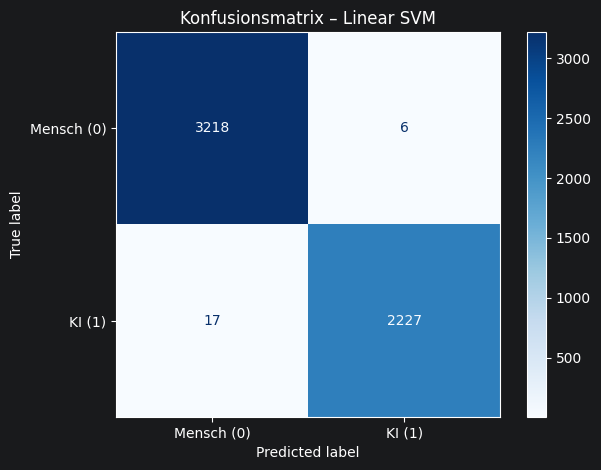

In [41]:
cm = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Mensch (0)", "KI (1)"]).plot(cmap="Blues")
plt.title(f"Konfusionsmatrix – {best_pipeline_name}")
plt.tight_layout()
plt.show()


#### Vertiefung: Lernkurve (Train-Size vs. Val-Accuracy)

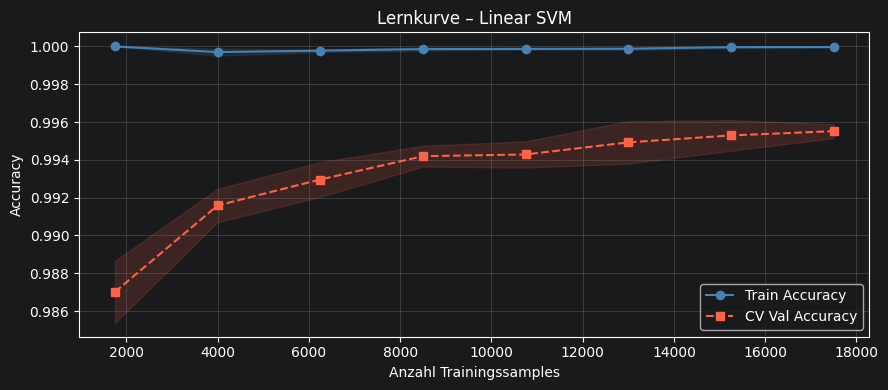

In [42]:
# Lernkurve für das beste Modell
best_pipeline_name = cv_df.iloc[0]["Modell"]
best_pipeline      = pipelines[best_pipeline_name]

train_sizes, train_scores, val_scores = learning_curve(
    best_pipeline, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    train_sizes=np.linspace(0.1, 1.0, 8),
    scoring="accuracy", n_jobs=-1
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_sizes, train_scores.mean(axis=1), "o-", color="steelblue", label="Train Accuracy")
ax.fill_between(train_sizes,
                train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15, color="steelblue")
ax.plot(train_sizes, val_scores.mean(axis=1), "s--", color="tomato", label="CV Val Accuracy")
ax.fill_between(train_sizes,
                val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15, color="tomato")

ax.set_xlabel("Anzahl Trainingssamples")
ax.set_ylabel("Accuracy")
ax.set_title(f"Lernkurve – {best_pipeline_name}")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Interpretation der Lernkurve:**
- Nähern sich Train- und Val-Kurve an → das Modell generalisiert gut.
- Großer Abstand → Overfitting (mehr Daten oder Regularisierung helfen).
- Val-Kurve steigt noch → mehr Daten würden die Performance weiter verbessern.

[Eigene Interpretation eintragen]

#### Stichprobe: Vorhersage vs. echter Wert

In [43]:
sample_idx   = X_test.sample(10, random_state=7).index
sample_texts = X_test.loc[sample_idx]
sample_true  = y_test.loc[sample_idx]
sample_pred  = best_pipeline.predict(sample_texts)

pd.DataFrame({
    "Text (Ausschnitt)": [t[:80] + "..." for t in sample_texts],
    "Wahrer Wert":       sample_true.values,
    "Vorhersage":        sample_pred,
    "Korrekt?":          ["ja" if t==p else "nein" for t, p in zip(sample_true.values, sample_pred)]
})


,Text (Ausschnitt),Wahrer Wert,Vorhersage,Korrekt?
0,"From saving money to having less polution, lim...",0,0,ja
1,Not too long ago I got into a disagreement wit...,0,0,ja
2,This painting is was made a long time ago. Man...,0,0,ja
3,The concept of free will has been a topic of d...,1,1,ja
4,In today's society cell phones and technology ...,0,0,ja
5,"The face on Mars was not made by aliens, and i...",0,0,ja
6,I say we should keep the Electoral collage. Th...,0,0,ja
7,"Dear Senator,\r\n\r\nI am writing to express m...",1,1,ja
8,"The world is advancing, technologies are being...",0,0,ja
9,Why would seeking multiple opinions about advi...,0,0,ja


#### Visualisierung – CV-Ergebnisse im Vergleich

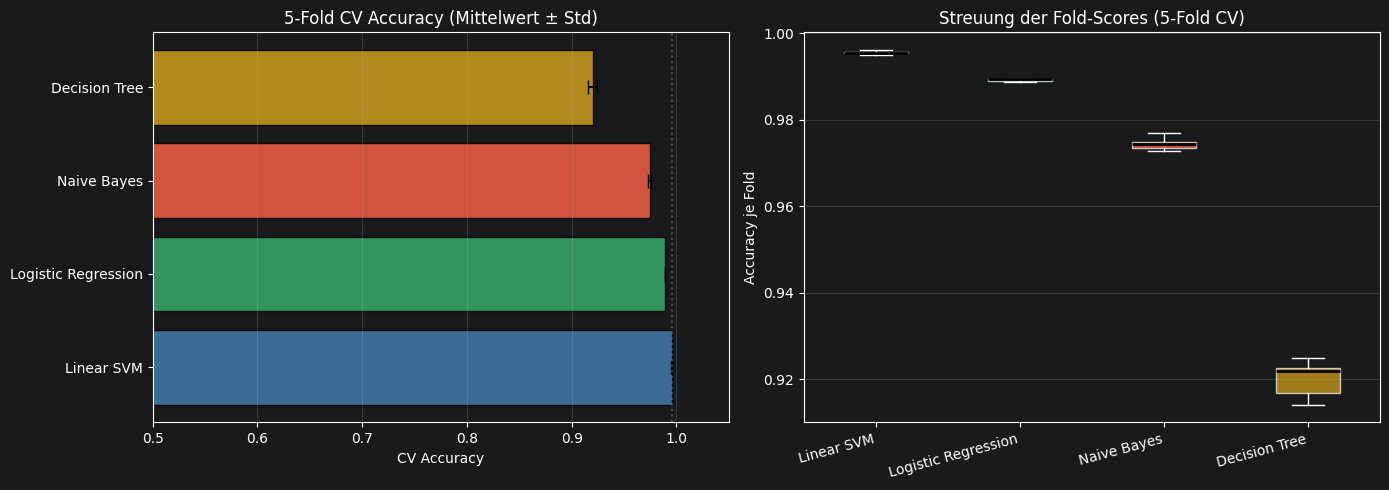

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Balkenplot: CV Mean ± Std
models_sorted = cv_df["Modell"].tolist()
means  = cv_df["CV Mean Acc"].tolist()
stds   = cv_df["CV Std Acc"].tolist()
colors = ["steelblue", "mediumseagreen", "tomato", "goldenrod"]

axes[0].barh(models_sorted, means, xerr=stds, align="center",
             color=colors[:len(models_sorted)], alpha=0.8, capsize=5, edgecolor="black")
axes[0].set_xlabel("CV Accuracy")
axes[0].set_title("5-Fold CV Accuracy (Mittelwert ± Std)")
axes[0].set_xlim(0.5, 1.05)
axes[0].axvline(x=max(means), color="gray", linestyle=":", alpha=0.5)
axes[0].grid(axis="x", alpha=0.3)

# (b) Boxplot: Verteilung der Fold-Scores
fold_data  = [row["Fold Scores"] for _, row in cv_df.iterrows()]
bp = axes[1].boxplot(fold_data, labels=models_sorted, patch_artist=True,
                     medianprops={"color": "black", "linewidth": 2})
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel("Accuracy je Fold")
axes[1].set_title("Streuung der Fold-Scores (5-Fold CV)")
axes[1].set_xticklabels(models_sorted, rotation=15, ha="right")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


**Beobachtung:**
- Ein **niedriges Std** zeigt, dass das Modell stabil über alle Folds performt.
- Ein **hohes Std** deutet auf Sensitivität gegenüber dem gewählten Split hin.
- [Eigene Beobachtungen eintragen: Welches Modell ist am stabilsten? Welches am besten?]


#### Erkenntnisse & Bewertung

##### Zusammenfassung

| Modell | CV Accuracy (Ø) | CV Std | Test Accuracy |
|--------|----------------|--------|---------------|
| [eintragen] | | | |

##### Warum ist Cross-Validation besser als ein einfacher Split?

- Ein einzelner Train/Val-Split kann je nach Zufall der Aufteilung stark variieren.
- 5-Fold CV nutzt die Daten effizienter – jeder Datenpunkt wird einmal validiert.
- Das Std der Fold-Scores zeigt, wie stabil das Modell wirklich ist.

##### Stärken von k-Fold CV

- Robustere Modellschätzung, weniger zufällig
- Gibt Aufschluss über Modellstabilität (Std)

##### Schwächen von k-Fold mit CV

- k-facher Rechenaufwand gegenüber einfachem Split
- Bei sehr großen Datensätzen oft impraktikabel

##### Was haben wir erwartet / Was hat überrascht?

[Eigene Reflexion der Gruppe eintragen]

### Entscheidungsbäume

#### Theoretischer Hintergrund

**Entscheidungsbäume** treffen Vorhersagen durch eine Folge von Ja/Nein-Entscheidungen (Splits):
- Jeder **Knoten** stellt eine Bedingung auf ein Feature dar.
- Jedes **Blatt** enthält die finale Vorhersage.
- Der Baum wird gelernt, indem bei jedem Schritt der Split gewählt wird, der die Daten am besten trennt.

**Klassifikationsbaum** → diskrete Zielvariable (z.B. Mensch vs. KI)
- Splitting-Kriterium: **Gini-Impurity** oder **Entropie (Information Gain)**

**Regressionsbaum** → kontinuierliche Zielvariable (z.B. Textlänge vorhersagen)
- Splitting-Kriterium: **Mean Squared Error (MSE)**

**Wichtigste Hyperparameter:**
- `max_depth`: Maximale Tiefe des Baums (begrenzt Overfitting)
- `min_samples_split`: Minimale Anzahl Samples, um einen Knoten zu splitten
- `min_samples_leaf`: Minimale Anzahl Samples in einem Blatt

#### Regressionsbaum

##### Train / Validation / Test Split

In [9]:
# Textlänge in Zeichen
df["text_length"] = df["text"].str.len()

# Wörter extrahieren
words = df["text"].apply(lambda x: re.findall(r"\b\w+\b", str(x)))

# Anzahl Wörter
df["word_count"] = words.apply(len)

# Anzahl Sätze
df["sentence_count"] = df["text"].apply(
    lambda x: len(re.findall(r"[.!?]+", str(x)))
)

# Durchschnittliche Wortlänge
df["avg_word_length"] = words.apply(
    lambda w: sum(len(word) for word in w) / len(w) if len(w) > 0 else 0
)

# Verhältnis unterschiedlicher Wörter
df["unique_word_ratio"] = words.apply(
    lambda w: len(set(word.lower() for word in w)) / len(w) if len(w) > 0 else 0
)

# Numerische Features als Input, Textlänge als Ziel
feature_cols = ["word_count", "sentence_count", "avg_word_length", "unique_word_ratio", "generated"]
X_reg = df[feature_cols]
y_reg = df["text_length"]

X_trainval_r, X_test_r, y_trainval_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
X_train_r, X_val_r, y_train_r, y_val_r = train_test_split(
    X_trainval_r, y_trainval_r, test_size=0.25, random_state=42
)

print(f"Trainingsdaten:    {len(X_train_r):>5} Samples")
print(f"Validierungsdaten: {len(X_val_r):>5} Samples")
print(f"Testdaten:         {len(X_test_r):>5} Samples")

# Kurzübersicht der Zielvariable
print(f"\nTextlänge (Zeichen):")
print(f"  Min:    {y_reg.min():.0f}")
print(f"  Max:    {y_reg.max():.0f}")
print(f"  Mittel: {y_reg.mean():.0f}")


Trainingsdaten:    17487 Samples
Validierungsdaten:  5829 Samples
Testdaten:          5829 Samples

Textlänge (Zeichen):
  Min:    1
  Max:    9169
  Mittel: 2244


##### max_depth vergleichen

In [12]:
depths_r  = [1, 2, 3, 5, 7, 10, None]
results_r = []

for depth in depths_r:
    reg = DecisionTreeRegressor(max_depth=depth, random_state=42)
    reg.fit(X_train_r, y_train_r)

    train_rmse = mean_squared_error(y_train_r, reg.predict(X_train_r))
    val_rmse   = mean_squared_error(y_val_r, reg.predict(X_val_r))
    val_r2     = r2_score(y_val_r,             reg.predict(X_val_r))

    label = str(depth) if depth is not None else "unbegrenzt"
    results_r.append({"max_depth": label, "Train RMSE": round(train_rmse, 1),
                       "Val RMSE": round(val_rmse, 1), "Val R²": round(val_r2, 4)})
    print(f"max_depth={label:>12} | Train RMSE: {train_rmse:.1f} | Val RMSE: {val_rmse:.1f} | Val R²: {val_r2:.4f}")

reg_df = pd.DataFrame(results_r)
reg_df


max_depth=           1 | Train RMSE: 401937.3 | Val RMSE: 419711.1 | Val R²: 0.5737
max_depth=           2 | Train RMSE: 143628.4 | Val RMSE: 154514.2 | Val R²: 0.8431
max_depth=           3 | Train RMSE: 72466.9 | Val RMSE: 74059.1 | Val R²: 0.9248
max_depth=           5 | Train RMSE: 24697.5 | Val RMSE: 23581.0 | Val R²: 0.9761
max_depth=           7 | Train RMSE: 9073.6 | Val RMSE: 9637.6 | Val R²: 0.9902
max_depth=          10 | Train RMSE: 1558.3 | Val RMSE: 5885.5 | Val R²: 0.9940
max_depth=  unbegrenzt | Train RMSE: 1.1 | Val RMSE: 5583.0 | Val R²: 0.9943


,max_depth,Train RMSE,Val RMSE,Val R²
0,1,401937.3,419711.1,0.5737
1,2,143628.4,154514.2,0.8431
2,3,72466.9,74059.1,0.9248
3,5,24697.5,23581.0,0.9761
4,7,9073.6,9637.6,0.9902
5,10,1558.3,5885.5,0.9940
6,unbegrenzt,1.1,5583.0,0.9943


**Metriken für Regression:**
- **RMSE** (Root Mean Squared Error): Durchschnittlicher Fehler in Zeichen – kleiner ist besser.
- **R²** (Bestimmtheitsmaß): Anteil der erklärten Varianz – 1.0 = perfekt, 0.0 = nutzlos.


##### Bestes Regressionsmodell auf Testdaten

In [14]:
best_depth_r_label = reg_df.loc[reg_df["Val RMSE"].idxmin(), "max_depth"]
best_depth_r_val   = None if best_depth_r_label == "unbegrenzt" else int(best_depth_r_label)
print(f"Gewähltes max_depth: {best_depth_r_label}")

reg_best = DecisionTreeRegressor(max_depth=best_depth_r_val, random_state=42)
reg_best.fit(X_train_r, y_train_r)

y_pred_reg  = reg_best.predict(X_test_r)
test_rmse   = mean_squared_error(y_test_r, y_pred_reg)
test_mae    = mean_absolute_error(y_test_r, y_pred_reg)
test_r2     = r2_score(y_test_r, y_pred_reg)

print(f"\nTest RMSE: {test_rmse:.1f} Zeichen")
print(f"Test MAE:  {test_mae:.1f} Zeichen")
print(f"Test R²:   {test_r2:.4f}")


Gewähltes max_depth: unbegrenzt

Test RMSE: 7899.7 Zeichen
Test MAE:  23.6 Zeichen
Test R²:   0.9920


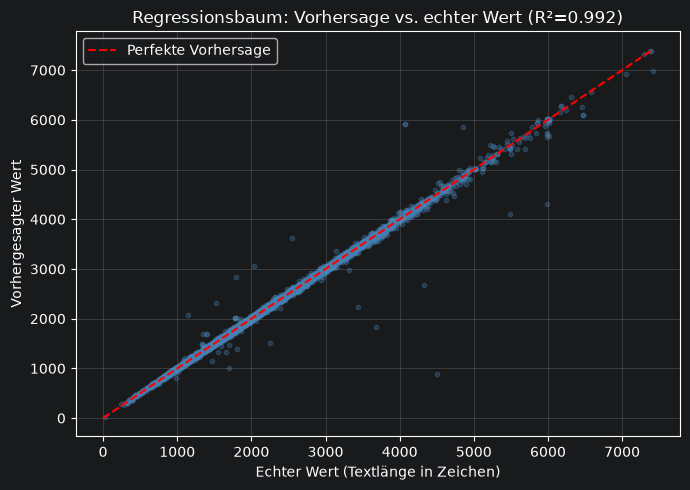

In [15]:
# Vorhersage vs. echter Wert
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test_r, y_pred_reg, alpha=0.3, s=10, color="steelblue")
lim = max(y_test_r.max(), y_pred_reg.max())
ax.plot([0, lim], [0, lim], "r--", label="Perfekte Vorhersage")
ax.set_xlabel("Echter Wert (Textlänge in Zeichen)")
ax.set_ylabel("Vorhergesagter Wert")
ax.set_title(f"Regressionsbaum: Vorhersage vs. echter Wert (R²={test_r2:.3f})")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


##### Stichprobe

In [16]:
sample_r = X_test_r.sample(10, random_state=7)
pred_r   = reg_best.predict(sample_r)
true_r   = y_test_r.loc[sample_r.index]

pd.DataFrame({
    "Wortanzahl":       sample_r["word_count"].values,
    "Echter Wert (Zeichen)":     true_r.values,
    "Vorhersage (Zeichen)":      pred_r.round(0).astype(int),
    "Abweichung":       (pred_r - true_r.values).round(0).astype(int)
})


,Wortanzahl,Echter Wert (Zeichen),Vorhersage (Zeichen),Abweichung
0,200,1052,1073,21
1,605,3322,3350,28
2,490,2537,2512,-25
3,428,2227,2227,0
4,740,4642,4691,49
5,450,2220,2245,25
6,276,1681,1680,-1
7,538,2879,2879,0
8,295,1652,1655,3
9,193,1103,1084,-19


##### Visualisierung – RMSE & R² nach Tiefe

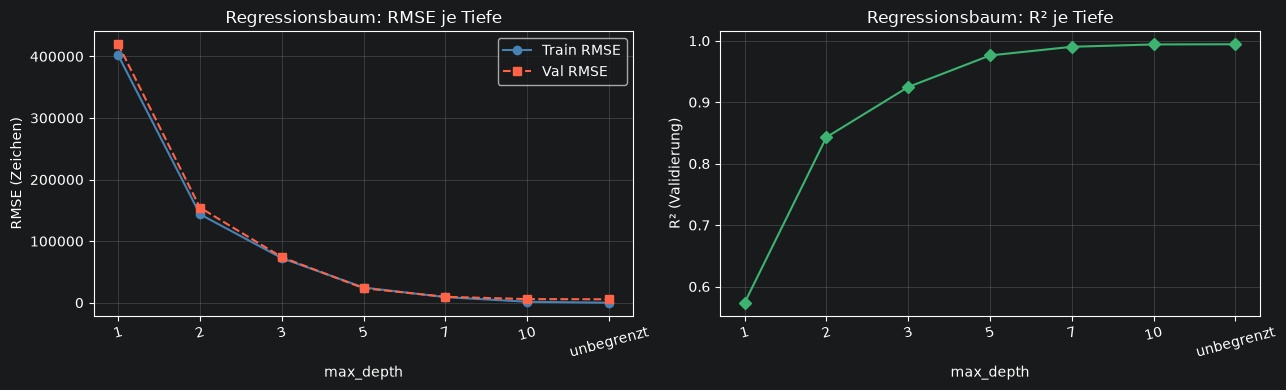

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

x = range(len(reg_df))
ax1.plot(x, reg_df["Train RMSE"], marker="o", color="steelblue", label="Train RMSE")
ax1.plot(x, reg_df["Val RMSE"],   marker="s", color="tomato",    label="Val RMSE", linestyle="--")
ax1.set_xticks(list(x))
ax1.set_xticklabels(reg_df["max_depth"], rotation=15)
ax1.set_xlabel("max_depth")
ax1.set_ylabel("RMSE (Zeichen)")
ax1.set_title("Regressionsbaum: RMSE je Tiefe")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(x, reg_df["Val R²"], marker="D", color="mediumseagreen")
ax2.set_xticks(list(x))
ax2.set_xticklabels(reg_df["max_depth"], rotation=15)
ax2.set_xlabel("max_depth")
ax2.set_ylabel("R² (Validierung)")
ax2.set_title("Regressionsbaum: R² je Tiefe")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


##### Erkenntnisse & Bewertung

###### Zusammenfassung

| Bestes max_depth | Val RMSE | Test RMSE | Test R² |
|-----------------|----------|-----------|---------|
| [eintragen]     | [eintragen] | [eintragen] | [eintragen] |

###### Was haben wir erwartet / Was hat überrascht?

[Eigene Reflexion der Gruppe eintragen]

#### Klassifikationsbaum

##### Train / Validation / Test Split

In [50]:
X_text = df["text"]
y_cls  = df["generated"]

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_text, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval
)

print(f"Trainingsdaten:    {len(X_train):>5} Samples")
print(f"Validierungsdaten: {len(X_val):>5} Samples")
print(f"Testdaten:         {len(X_test):>5} Samples")


Trainingsdaten:    16404 Samples
Validierungsdaten:  5468 Samples
Testdaten:          5468 Samples


##### Feature Extraction – TF-IDF

In [51]:
tfidf = TfidfVectorizer(max_features=5000, sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)
print(f"TF-IDF Feature-Matrix (Train): {X_train_tfidf.shape}")


TF-IDF Feature-Matrix (Train): (16404, 5000)


##### Hyperparameter `max_depth` vergleichen

In [52]:
depths  = [1, 2, 3, 5, 7, 10, 15, None]
results = []

for depth in depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42, criterion="gini")
    clf.fit(X_train_tfidf, y_train)

    train_acc = accuracy_score(y_train, clf.predict(X_train_tfidf))
    val_acc   = accuracy_score(y_val,   clf.predict(X_val_tfidf))

    label = str(depth) if depth is not None else "unbegrenzt"
    results.append({"max_depth": label, "Train Acc": round(train_acc, 4), "Val Acc": round(val_acc, 4)})
    print(f"max_depth={label:>12} | Train: {train_acc:.4f} | Val: {val_acc:.4f}")

cls_df = pd.DataFrame(results)
cls_df


max_depth=           1 | Train: 0.7576 | Val: 0.7588
max_depth=           2 | Train: 0.8180 | Val: 0.8206
max_depth=           3 | Train: 0.8474 | Val: 0.8469
max_depth=           5 | Train: 0.8910 | Val: 0.8789
max_depth=           7 | Train: 0.9256 | Val: 0.9049
max_depth=          10 | Train: 0.9516 | Val: 0.9139
max_depth=          15 | Train: 0.9709 | Val: 0.9296
max_depth=  unbegrenzt | Train: 1.0000 | Val: 0.9340


,max_depth,Train Acc,Val Acc
0,1,0.7576,0.7588
1,2,0.8180,0.8206
2,3,0.8474,0.8469
3,5,0.8910,0.8789
4,7,0.9256,0.9049
5,10,0.9516,0.9139
6,15,0.9709,0.9296
7,unbegrenzt,1.0000,0.9340


##### Bestes Klassifikationsmodell auf Testdaten

In [53]:
best_depth = cls_df.loc[cls_df["Val Acc"].idxmax(), "max_depth"]
best_depth_val = None if best_depth == "unbegrenzt" else int(best_depth)
print(f"Gewähltes max_depth: {best_depth}")

clf_best = DecisionTreeClassifier(max_depth=best_depth_val, random_state=42, criterion="gini")
clf_best.fit(X_train_tfidf, y_train)

y_pred_test = clf_best.predict(X_test_tfidf)
test_acc    = accuracy_score(y_test, y_pred_test)

print(f"Test Accuracy: {test_acc:.4f}")
print("\nKlassifikationsbericht:")
print(classification_report(y_test, y_pred_test, target_names=["Mensch (0)", "KI (1)"]))


Gewähltes max_depth: unbegrenzt
Test Accuracy: 0.9323

Klassifikationsbericht:
              precision    recall  f1-score   support

  Mensch (0)       0.95      0.94      0.94      3224
      KI (1)       0.91      0.92      0.92      2244

    accuracy                           0.93      5468
   macro avg       0.93      0.93      0.93      5468
weighted avg       0.93      0.93      0.93      5468



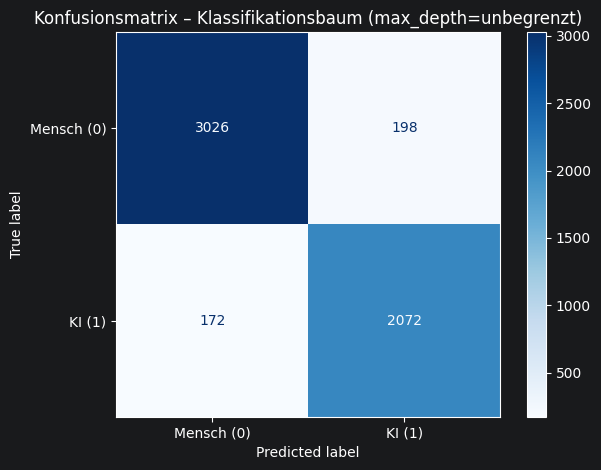

In [54]:
cm = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Mensch (0)", "KI (1)"]).plot(cmap="Blues")
plt.title(f"Konfusionsmatrix – Klassifikationsbaum (max_depth={best_depth})")
plt.tight_layout()
plt.show()


##### Stichprobe

In [55]:
sample_idx   = X_test.sample(10, random_state=7).index
sample_texts = X_test.loc[sample_idx]
sample_true  = y_test.loc[sample_idx]
sample_pred  = clf_best.predict(tfidf.transform(sample_texts))

pd.DataFrame({
    "Text (Ausschnitt)": [t[:80] + "..." for t in sample_texts],
    "Wahrer Wert":       sample_true.values,
    "Vorhersage":        sample_pred,
    "Korrekt?":          ["ja" if t==p else "nein" for t, p in zip(sample_true.values, sample_pred)]
})


,Text (Ausschnitt),Wahrer Wert,Vorhersage,Korrekt?
0,"From saving money to having less polution, lim...",0,0,ja
1,Not too long ago I got into a disagreement wit...,0,0,ja
2,This painting is was made a long time ago. Man...,0,0,ja
3,The concept of free will has been a topic of d...,1,1,ja
4,In today's society cell phones and technology ...,0,0,ja
5,"The face on Mars was not made by aliens, and i...",0,0,ja
6,I say we should keep the Electoral collage. Th...,0,0,ja
7,"Dear Senator,\r\n\r\nI am writing to express m...",1,1,ja
8,"The world is advancing, technologies are being...",0,0,ja
9,Why would seeking multiple opinions about advi...,0,0,ja


##### Visualisierung – Einfluss von max_depth

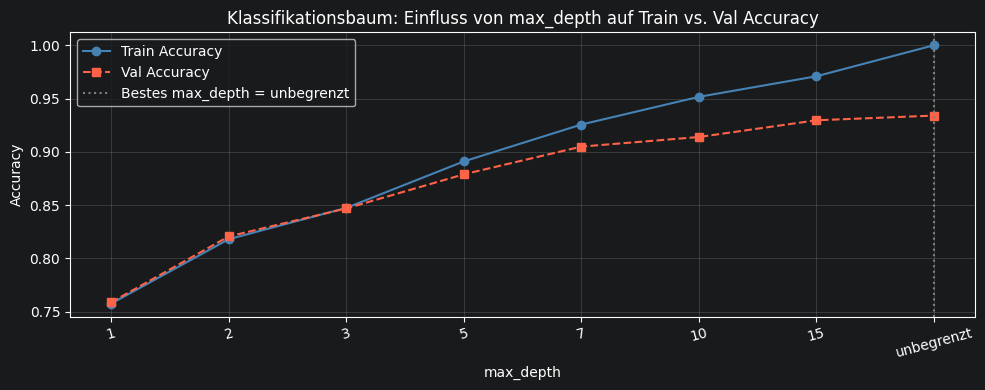

In [56]:
fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(cls_df))
ax.plot(x, cls_df["Train Acc"], marker="o", color="steelblue", label="Train Accuracy")
ax.plot(x, cls_df["Val Acc"],   marker="s", color="tomato",    label="Val Accuracy", linestyle="--")

best_idx = cls_df["Val Acc"].idxmax()
ax.axvline(x=best_idx, color="gray", linestyle=":", label=f"Bestes max_depth = {cls_df.loc[best_idx,'max_depth']}")

ax.set_xticks(list(x))
ax.set_xticklabels(cls_df["max_depth"], rotation=15)
ax.set_xlabel("max_depth")
ax.set_ylabel("Accuracy")
ax.set_title("Klassifikationsbaum: Einfluss von max_depth auf Train vs. Val Accuracy")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Beobachtung:**
- Sehr kleine Tiefe (z.B. 1–2) → Underfitting: zu einfaches Modell, lernt die Daten nicht ausreichend.
- Sehr große Tiefe / unbegrenzt → Overfitting: hohe Train-Accuracy, aber schlechtere Val-Accuracy.
- Optimale Tiefe liegt dazwischen. [Eigenen besten Wert eintragen]


##### Baum-Visualisierung (vereinfacht mit max_depth=3)

In [57]:
# Trainierten Baum mit max_depth=3 visualisieren (gut lesbar)
clf_vis = DecisionTreeClassifier(max_depth=3, random_state=42, criterion="gini")
clf_vis.fit(X_train_tfidf, y_train)

# Wichtigste Features
feature_names = tfidf.get_feature_names_out()
importances   = clf_vis.feature_importances_
top_idx       = importances.argsort()[::-1][:10]
print("Top-10 wichtigste Features:")
for i in top_idx:
    if importances[i] > 0:
        print(f"  '{feature_names[i]}': {importances[i]:.4f}")


Top-10 wichtigste Features:
  'because': 0.5388
  'would': 0.1764
  'additionally': 0.1368
  'was': 0.0774
  'essential': 0.0612
  'very': 0.0094


In [58]:
# Baumstruktur als Text ausgeben
print(export_text(clf_vis, feature_names=list(feature_names), max_depth=3))


|--- because <= 0.01
|   |--- would <= 0.03
|   |   |--- was <= 0.03
|   |   |   |--- class: 1
|   |   |--- was >  0.03
|   |   |   |--- class: 0
|   |--- would >  0.03
|   |   |--- additionally <= 0.03
|   |   |   |--- class: 0
|   |   |--- additionally >  0.03
|   |   |   |--- class: 1
|--- because >  0.01
|   |--- additionally <= 0.03
|   |   |--- essential <= 0.04
|   |   |   |--- class: 0
|   |   |--- essential >  0.04
|   |   |   |--- class: 1
|   |--- additionally >  0.03
|   |   |--- very <= 0.01
|   |   |   |--- class: 1
|   |   |--- very >  0.01
|   |   |   |--- class: 0



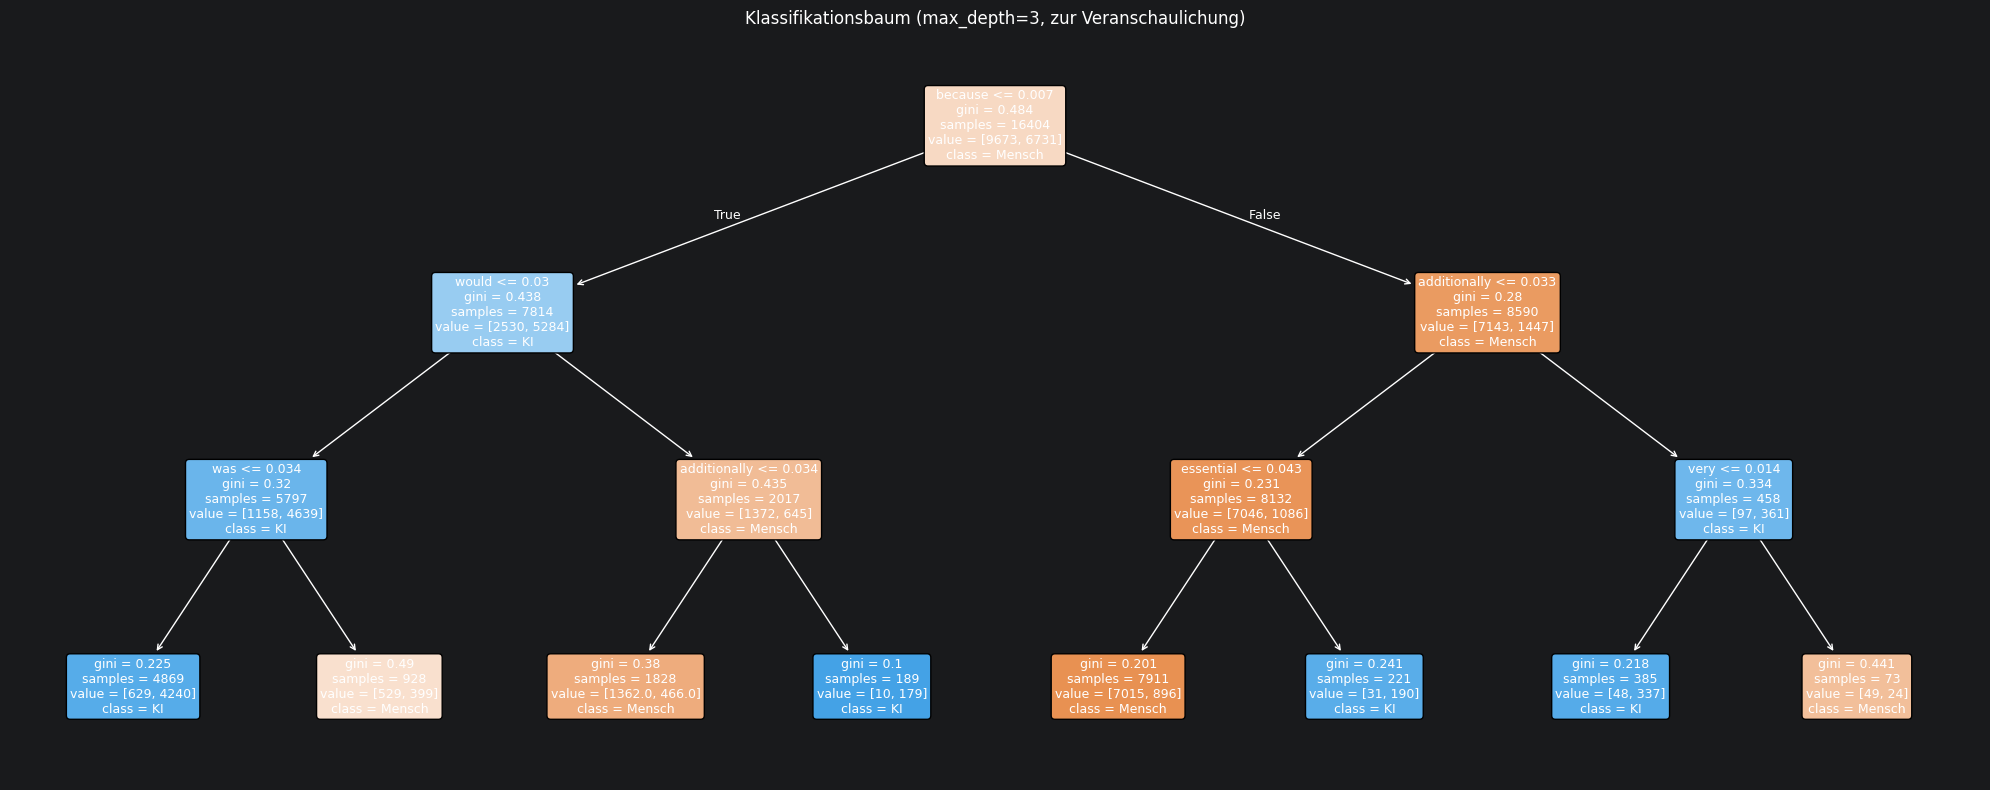

In [59]:
# Grafische Darstellung
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(clf_vis, max_depth=3, feature_names=feature_names,
          class_names=["Mensch", "KI"], filled=True, rounded=True,
          fontsize=9, ax=ax)
plt.title("Klassifikationsbaum (max_depth=3, zur Veranschaulichung)")
plt.tight_layout()
plt.show()


##### Erkenntnisse & Bewertung

###### Zusammenfassung

| Bestes max_depth | Val Accuracy | Test Accuracy |
|-----------------|-------------|---------------|
| [eintragen]     | [eintragen] | [eintragen]   |

###### Was haben wir erwartet / Was hat überrascht?

[Eigene Reflexion der Gruppe eintragen]

### Stärken von Entscheidungsbäumen

- Sehr gut interpretierbar (visuell darstellbar)
- Kein Feature-Scaling notwendig
- Kann sowohl Klassifikation als auch Regression

### Schwächen von Entscheidungsbäumen

- Neigen stark zu Overfitting (tiefer Baum = sehr hohe Train Accuracy, aber schlechte Generalisierung)
- Instabil: Kleine Datenänderungen können den Baum stark verändern
- Für Textdaten mit TF-IDF: Random Forest/Gradient Boosting meist besser

### Unterschied Klassifikations- vs. Regressionsbaum

| Aspekt | Klassifikationsbaum | Regressionsbaum |
|--------|---------------------|-----------------|
| Zielvariable | Diskret (Klassen) | Kontinuierlich |
| Splitting-Kriterium | Gini / Entropie | MSE |
| Blatt-Vorhersage | Mehrheitsvotum | Mittelwert |
| Metriken | Accuracy, F1 | RMSE, MAE, R² |

### Random Forest

#### Theoretischer Hintergrund

Ein **Random Forest** ist ein Ensemble-Modell, das viele Entscheidungsbäume kombiniert:

1. Es werden **n Entscheidungsbäume** trainiert – jeder auf einem zufälligen Teil der Daten (Bootstrap-Sampling).
2. Bei jedem Split wird nur eine **zufällige Teilmenge der Features** betrachtet (Feature Randomness).
3. Die finale Vorhersage entsteht durch **Mehrheitsvotum** aller Bäume (Klassifikation) bzw. den Mittelwert (Regression).

**Warum ist das besser als ein einzelner Baum?**
Ein einzelner Baum neigt stark zu Overfitting. Durch die Kombination vieler verschiedener Bäume mitteln sich Fehler heraus – das Modell wird **stabiler und generalisiert besser** (Bias-Variance-Tradeoff).

**Wichtige Hyperparameter:**

| Parameter | Bedeutung | Typische Werte |
|-----------|-----------|----------------|
| `n_estimators` | Anzahl der Bäume | 50, 100, 200, 500 |
| `max_depth` | Maximale Tiefe je Baum | 5, 10, 20, None |
| `max_features` | Features je Split | `"sqrt"`, `"log2"`, 0.5 |
| `min_samples_leaf` | Min. Samples je Blatt | 1, 2, 5 |

#### Train / Validation / Test Split

Der Datensatz wird in drei Teile aufgeteilt:
- **Trainingsdaten (60 %)** – Modell trainieren
- **Validierungsdaten (20 %)** – Hyperparameter vergleichen
- **Testdaten (20 %)** – nur für die finale Evaluation des besten Modells

_Wichtig:_ Testdaten werden erst ganz am Ende verwendet!

In [60]:
X = df["text"]
y = df["generated"]

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval
)

print(f"Trainingsdaten:    {len(X_train):>5} Samples ({len(X_train)/len(X)*100:.0f}%)")
print(f"Validierungsdaten: {len(X_val):>5} Samples ({len(X_val)/len(X)*100:.0f}%)")
print(f"Testdaten:         {len(X_test):>5} Samples ({len(X_test)/len(X)*100:.0f}%)")


Trainingsdaten:    16404 Samples (60%)
Validierungsdaten:  5468 Samples (20%)
Testdaten:          5468 Samples (20%)


#### Feature Extraction – TF-IDF

Random Forests können nicht direkt mit Rohtexten arbeiten. Wir verwenden TF-IDF, um den Text in eine numerische Matrix umzuwandeln, und kombinieren das mit dem Random Forest in einer **Pipeline** (verhindert Data Leakage).

In [61]:
# Basis-Pipeline: TF-IDF + Random Forest
base_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000, sublinear_tf=True)),
    ("clf",   RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
])

base_pipeline.fit(X_train, y_train)
train_acc = accuracy_score(y_train, base_pipeline.predict(X_train))
val_acc   = accuracy_score(y_val,   base_pipeline.predict(X_val))

print(f"Basis-Modell (n_estimators=100)")
print(f"  Train Accuracy: {train_acc:.4f}")
print(f"  Val   Accuracy: {val_acc:.4f}")


Basis-Modell (n_estimators=100)
  Train Accuracy: 1.0000
  Val   Accuracy: 0.9821


#### Hyperparameter vergleichen

Wir variieren zwei zentrale Parameter:
- **`n_estimators`**: Wie viele Bäume werden trainiert?
- **`max_depth`**: Wie tief darf jeder Baum wachsen?

##### Experiment 1: Einfluss von `n_estimators`

In [62]:
n_estimators_list = [10, 25, 50, 100, 200, 300]
results_n = []

for n in n_estimators_list:
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=10000, sublinear_tf=True)),
        ("clf",   RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)),
    ])
    pipe.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, pipe.predict(X_train))
    val_acc   = accuracy_score(y_val,   pipe.predict(X_val))
    results_n.append({"n_estimators": n, "Train Accuracy": round(train_acc, 4), "Val Accuracy": round(val_acc, 4)})
    print(f"n_estimators={n:>4} | Train: {train_acc:.4f} | Val: {val_acc:.4f}")

results_n_df = pd.DataFrame(results_n)
results_n_df


n_estimators=  10 | Train: 0.9985 | Val: 0.9662
n_estimators=  25 | Train: 1.0000 | Val: 0.9764
n_estimators=  50 | Train: 1.0000 | Val: 0.9799
n_estimators= 100 | Train: 1.0000 | Val: 0.9821
n_estimators= 200 | Train: 1.0000 | Val: 0.9837
n_estimators= 300 | Train: 1.0000 | Val: 0.9845


,n_estimators,Train Accuracy,Val Accuracy
0,10,0.9985,0.9662
1,25,1.0000,0.9764
2,50,1.0000,0.9799
3,100,1.0000,0.9821
4,200,1.0000,0.9837
5,300,1.0000,0.9845


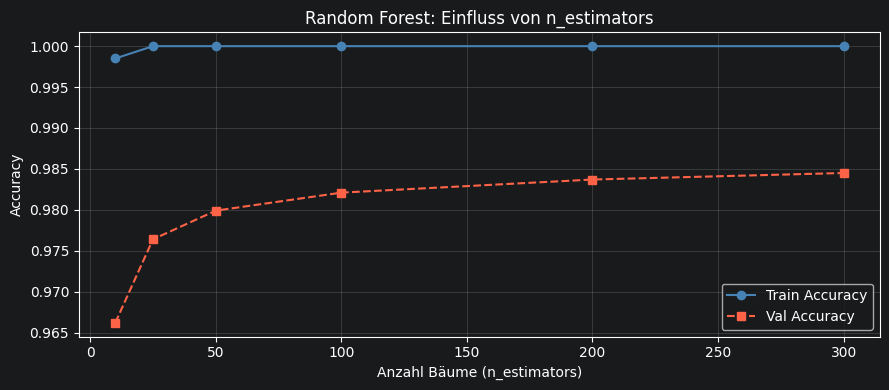

In [63]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(results_n_df["n_estimators"], results_n_df["Train Accuracy"], marker="o", color="steelblue", label="Train Accuracy")
ax.plot(results_n_df["n_estimators"], results_n_df["Val Accuracy"],   marker="s", color="tomato",    label="Val Accuracy", linestyle="--")
ax.set_xlabel("Anzahl Bäume (n_estimators)")
ax.set_ylabel("Accuracy")
ax.set_title("Random Forest: Einfluss von n_estimators")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Beobachtung:**
Ab einer gewissen Anzahl Bäume verbessert sich die Val-Accuracy kaum noch – aber die Rechenzeit steigt linear. Es gibt einen **Sweet Spot**, ab dem mehr Bäume keinen Mehrwert bringen.
[Eigene Beobachtung eintragen]


##### Experiment 2: Einfluss von `max_depth`

In [64]:
depths = [5, 10, 20, 30, None]
results_d = []

for depth in depths:
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=10000, sublinear_tf=True)),
        ("clf",   RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=42, n_jobs=-1)),
    ])
    pipe.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, pipe.predict(X_train))
    val_acc   = accuracy_score(y_val,   pipe.predict(X_val))
    label = str(depth) if depth is not None else "unbegrenzt"
    results_d.append({"max_depth": label, "Train Accuracy": round(train_acc, 4), "Val Accuracy": round(val_acc, 4)})
    print(f"max_depth={label:>12} | Train: {train_acc:.4f} | Val: {val_acc:.4f}")

results_d_df = pd.DataFrame(results_d)
results_d_df


max_depth=           5 | Train: 0.9281 | Val: 0.9276
max_depth=          10 | Train: 0.9746 | Val: 0.9623
max_depth=          20 | Train: 0.9943 | Val: 0.9779
max_depth=          30 | Train: 0.9995 | Val: 0.9817
max_depth=  unbegrenzt | Train: 1.0000 | Val: 0.9821


,max_depth,Train Accuracy,Val Accuracy
0,5,0.9281,0.9276
1,10,0.9746,0.9623
2,20,0.9943,0.9779
3,30,0.9995,0.9817
4,unbegrenzt,1.0000,0.9821


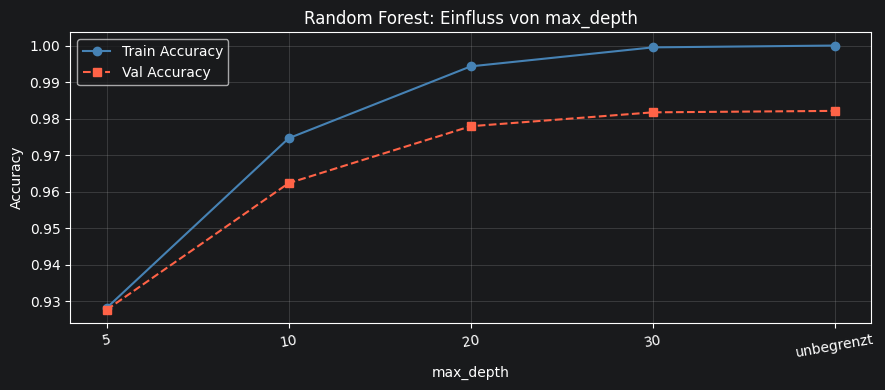

In [65]:
fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(results_d_df))
ax.plot(x, results_d_df["Train Accuracy"], marker="o", color="steelblue", label="Train Accuracy")
ax.plot(x, results_d_df["Val Accuracy"],   marker="s", color="tomato",    label="Val Accuracy", linestyle="--")
ax.set_xticks(list(x))
ax.set_xticklabels(results_d_df["max_depth"], rotation=10)
ax.set_xlabel("max_depth")
ax.set_ylabel("Accuracy")
ax.set_title("Random Forest: Einfluss von max_depth")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Beobachtung:**
Im Gegensatz zum einzelnen Entscheidungsbaum ist der Random Forest bei unbegrenzter Tiefe robuster gegen Overfitting – weil die Varianz durch das Ensemble ausgeglichen wird.
[Eigene Beobachtung eintragen]


#### Bestes Modell auf Testdaten evaluieren

In [67]:
best_n = results_n_df.loc[results_n_df["Val Accuracy"].idxmax(), "n_estimators"]

print(f"Gewählte Hyperparameter:")
print(f"  n_estimators = {int(best_n)}")
print(f"  max_depth    = {best_depth_val}")

best_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000, sublinear_tf=True)),
    ("clf",   RandomForestClassifier(n_estimators=int(best_n), max_depth=best_depth_val,
                                     random_state=42, n_jobs=-1)),
])
best_pipeline.fit(X_trainval, y_trainval)

y_pred_test = best_pipeline.predict(X_test)
test_acc    = accuracy_score(y_test, y_pred_test)

print(f"\nTest Accuracy: {test_acc:.4f}")
print("\nKlassifikationsbericht:")
print(classification_report(y_test, y_pred_test, target_names=["Mensch (0)", "KI (1)"]))


Gewählte Hyperparameter:
  n_estimators = 300
  max_depth    = None

Test Accuracy: 0.9852

Klassifikationsbericht:
              precision    recall  f1-score   support

  Mensch (0)       0.98      1.00      0.99      3224
      KI (1)       0.99      0.97      0.98      2244

    accuracy                           0.99      5468
   macro avg       0.99      0.98      0.98      5468
weighted avg       0.99      0.99      0.99      5468



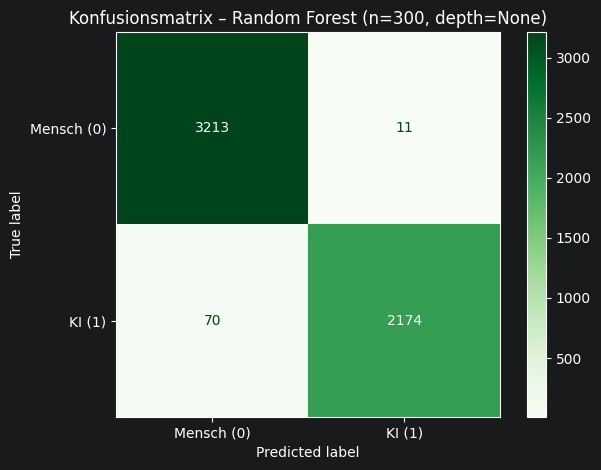

In [69]:
cm = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Mensch (0)", "KI (1)"]).plot(cmap="Greens")
plt.title(f"Konfusionsmatrix – Random Forest (n={int(best_n)}, depth={best_depth_val})")
plt.tight_layout()
plt.show()


#### Stichprobe: Vorhersage vs. echter Wert

In [70]:
sample_idx   = X_test.sample(10, random_state=7).index
sample_texts = X_test.loc[sample_idx]
sample_true  = y_test.loc[sample_idx]
sample_pred  = best_pipeline.predict(sample_texts)

pd.DataFrame({
    "Text (Ausschnitt)": [t[:80] + "..." for t in sample_texts],
    "Wahrer Wert":       sample_true.values,
    "Vorhersage":        sample_pred,
    "Korrekt?":          ["ja" if t==p else "nein" for t, p in zip(sample_true.values, sample_pred)]
})


,Text (Ausschnitt),Wahrer Wert,Vorhersage,Korrekt?
0,"From saving money to having less polution, lim...",0,0,ja
1,Not too long ago I got into a disagreement wit...,0,0,ja
2,This painting is was made a long time ago. Man...,0,0,ja
3,The concept of free will has been a topic of d...,1,1,ja
4,In today's society cell phones and technology ...,0,0,ja
5,"The face on Mars was not made by aliens, and i...",0,0,ja
6,I say we should keep the Electoral collage. Th...,0,0,ja
7,"Dear Senator,\r\n\r\nI am writing to express m...",1,1,ja
8,"The world is advancing, technologies are being...",0,0,ja
9,Why would seeking multiple opinions about advi...,0,0,ja


#### Visualisierung – Gesamtvergleich aller Parametervarianten

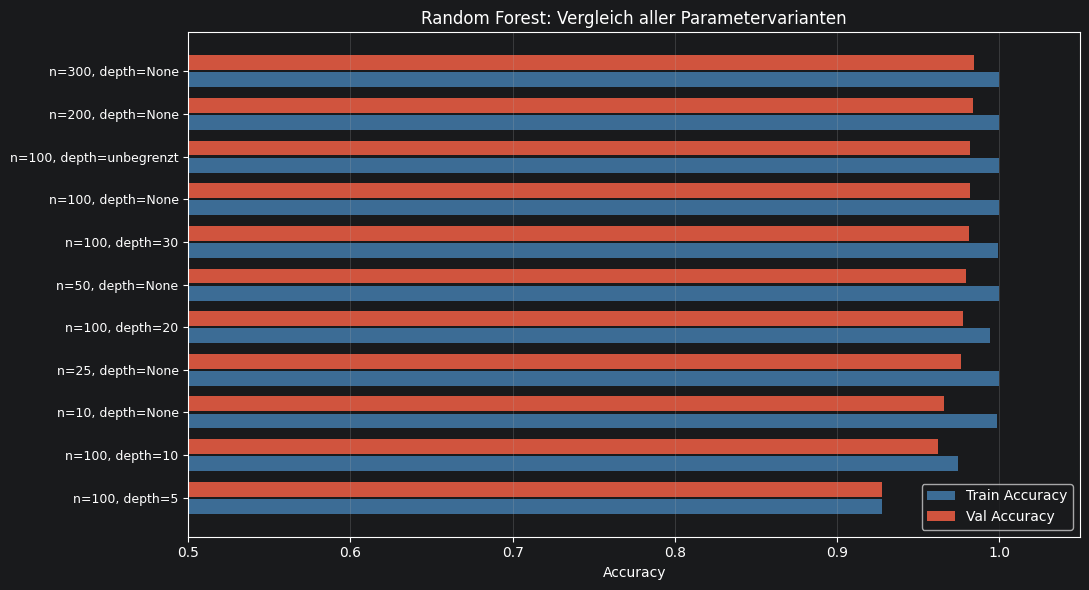

In [71]:
# Alle Ergebnisse zusammenführen
all_results = []
for _, row in results_n_df.iterrows():
    all_results.append({"Variante": f"n={int(row['n_estimators'])}, depth=None",
                        "Train Accuracy": row["Train Accuracy"], "Val Accuracy": row["Val Accuracy"]})
for _, row in results_d_df.iterrows():
    all_results.append({"Variante": f"n=100, depth={row['max_depth']}",
                        "Train Accuracy": row["Train Accuracy"], "Val Accuracy": row["Val Accuracy"]})

all_df = pd.DataFrame(all_results).sort_values("Val Accuracy", ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
y_pos = range(len(all_df))
ax.barh([i - 0.2 for i in y_pos], all_df["Train Accuracy"], height=0.35,
        color="steelblue", alpha=0.8, label="Train Accuracy")
ax.barh([i + 0.2 for i in y_pos], all_df["Val Accuracy"],   height=0.35,
        color="tomato",    alpha=0.8, label="Val Accuracy")
ax.set_yticks(list(y_pos))
ax.set_yticklabels(all_df["Variante"], fontsize=9)
ax.set_xlabel("Accuracy")
ax.set_title("Random Forest: Vergleich aller Parametervarianten")
ax.set_xlim(0.5, 1.05)
ax.legend()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


##### Feature Importance – Welche Wörter sind entscheidend?

In [72]:
# Bestes Modell aus n_estimators-Experiment für Feature Importance
pipe_fi = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000, sublinear_tf=True)),
    ("clf",   RandomForestClassifier(n_estimators=int(best_n), random_state=42, n_jobs=-1)),
])
pipe_fi.fit(X_train, y_train)

feature_names  = pipe_fi.named_steps["tfidf"].get_feature_names_out()
importances    = pipe_fi.named_steps["clf"].feature_importances_
top_idx        = importances.argsort()[::-1][:20]

top_features_df = pd.DataFrame({
    "Feature":    feature_names[top_idx],
    "Importance": importances[top_idx].round(5),
})
print("Top-20 wichtigste Features:")
top_features_df


Top-20 wichtigste Features:


,Feature,Importance
0,because,0.02302
1,would,0.01446
2,you,0.01425
3,but,0.01237
4,so,0.01237
5,if,0.01139
6,like,0.01123
7,get,0.01078
8,was,0.01026
9,just,0.00961


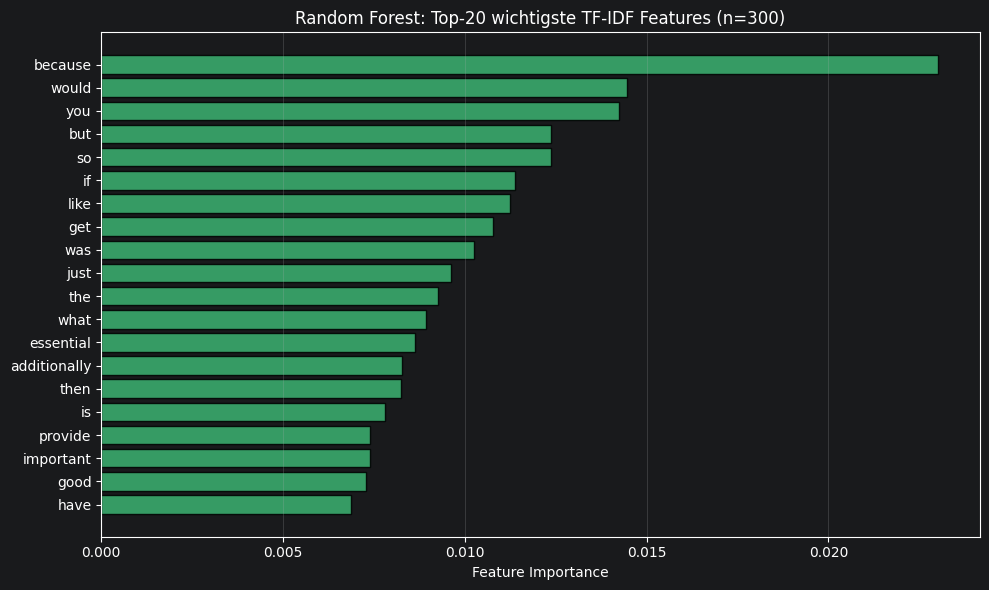

In [73]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_features_df["Feature"][::-1], top_features_df["Importance"][::-1],
        color="mediumseagreen", edgecolor="black", alpha=0.85)
ax.set_xlabel("Feature Importance")
ax.set_title(f"Random Forest: Top-20 wichtigste TF-IDF Features (n={best_n})")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


**Interpretation:**
Feature Importance zeigt, welche Wörter (TF-IDF-Features) am stärksten zur Klassifikation beitragen.
- Wörter mit hoher Importance trennen KI- und Menschentexte besonders gut.
- [Welche Wörter erscheinen bei euch? Ergeben sie inhaltlich Sinn?]


##### Cross-Validation des besten Modells

Zur Absicherung der Ergebnisse wenden wir zusätzlich eine 5-Fold Cross-Validation an.

In [74]:
best_depth_label = results_d_df.loc[results_d_df["Val Accuracy"].idxmax(), "max_depth"]
best_depth_val   = None if best_depth_label == "unbegrenzt" else int(best_depth_label)

cv_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000, sublinear_tf=True)),
    ("clf",   RandomForestClassifier(n_estimators=int(best_n), max_depth=best_depth_val,
                                     random_state=42, n_jobs=-1)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(cv_pipeline, X_trainval, y_trainval, cv=cv, scoring="accuracy", n_jobs=-1)

print(f"5-Fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Scores je Fold: {[round(s, 4) for s in cv_scores]}")


5-Fold CV Accuracy: 0.9832 ± 0.0009
Scores je Fold: [np.float64(0.9842), np.float64(0.9829), np.float64(0.984), np.float64(0.9817), np.float64(0.9831)]


#### Erkenntnisse & Bewertung

##### Zusammenfassung der Ergebnisse

| Konfiguration | Val Accuracy | Test Accuracy | CV Accuracy (Ø ± Std) |
|---------------|-------------|---------------|----------------------|
| Bestes Modell (n=[eintragen], depth=[eintragen]) | [eintragen] | [eintragen] | [eintragen] |

##### Vergleich mit anderen Modellen (aus vorherigen Notebooks)

| Modell | Val / CV Accuracy | Test Accuracy |
|--------|------------------|---------------|
| Logistic Regression | | |
| Naive Bayes | | |
| Linear SVM | | |
| Decision Tree | | |
| KNN | | |
| **Random Forest** | | |


##### Stärken von Random Forests

- Deutlich robuster gegen Overfitting als ein einzelner Entscheidungsbaum
- Liefert Feature Importance → Interpretierbarkeit bleibt erhalten
- Funktioniert gut ohne aufwändiges Preprocessing
- Stabil gegenüber Ausreißern und Rauschen in den Daten


##### Schwächen von Random Forests

- Rechenintensiv bei vielen Bäumen und großen Feature-Räumen (TF-IDF mit 10.000 Features)
- Weniger interpretierbar als ein einzelner Entscheidungsbaum
- Kein Wahrscheinlichkeitsoutput ohne Zusatzaufwand (`predict_proba`)

##### Was haben wir erwartet / Was hat überrascht?

[Eigene Reflexion der Gruppe eintragen]

### Deep Learning

#### Theoretischer Hintergrund

**Deep Learning** verwendet künstliche neuronale Netze mit mehreren Schichten, um komplexe, nicht-lineare Muster in Daten zu lernen. Für Textklassifikation gibt es zwei grundsätzlich unterschiedliche Ansätze:

**Ansatz 1: Feedforward-Netz (Dense) auf TF-IDF**
- Der Text wird zunächst klassisch via TF-IDF in einen festen Vektor umgewandelt.
- Dieser Vektor wird durch mehrere **Dense-Schichten** (vollständig verbundene Schichten) geschickt.
- **Nachteil:** Wortreihenfolge geht verloren (genau wie bei klassischem ML).

**Ansatz 2: Embedding + LSTM**
- Wörter werden zunächst in **dichte Vektoren (Embeddings)** übersetzt, die semantische Ähnlichkeit abbilden.
- Ein **LSTM (Long Short-Term Memory)** verarbeitet die Wortsequenz **in ihrer ursprünglichen Reihenfolge** und kann sich relevante Information über längere Sequenzen "merken".
- **Vorteil:** Berücksichtigt Kontext und Wortreihenfolge – wichtig für Sprachmuster, die LLMs hinterlassen.

**Wichtige Begriffe:**

| Begriff | Bedeutung |
|---------|-----------|
| Epoch | Ein vollständiger Durchlauf durch die Trainingsdaten |
| Batch Size | Anzahl Samples, die gleichzeitig verarbeitet werden |
| Dropout | Regularisierungstechnik gegen Overfitting (zufälliges Abschalten von Neuronen) |
| Embedding | Lernbare, dichte Vektorrepräsentation von Wörtern |
| Early Stopping | Training stoppt automatisch, wenn sich die Validierungsmetrik nicht mehr verbessert |

#### Vorbereitung

In [37]:
# Reproduzierbarkeit
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU verfügbar: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow Version: 2.21.0
GPU verfügbar: False


#### 1a. Train / Validation / Test Split

Wie bei den vorherigen Modellen: 60 % Training, 20 % Validierung, 20 % Test. Die Testdaten werden erst ganz am Ende verwendet.

In [40]:
X = df["text"].values
y = df["generated"].values

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval
)

print(f"Trainingsdaten:    {len(X_train):>5} Samples ({len(X_train)/len(X)*100:.0f}%)")
print(f"Validierungsdaten: {len(X_val):>5} Samples ({len(X_val)/len(X)*100:.0f}%)")
print(f"Testdaten:         {len(X_test):>5} Samples ({len(X_test)/len(X)*100:.0f}%)")

Trainingsdaten:    17487 Samples (60%)
Validierungsdaten:  5829 Samples (20%)
Testdaten:          5829 Samples (20%)


#### Teil 1: Feedforward-Netz (Dense) auf TF-IDF

##### 1b. Feature Extraction – TF-IDF

In [41]:
tfidf = TfidfVectorizer(max_features=10000, sublinear_tf=True)

X_train_tfidf = tfidf.fit_transform(X_train).toarray()
X_val_tfidf   = tfidf.transform(X_val).toarray()
X_test_tfidf  = tfidf.transform(X_test).toarray()

print(f"TF-IDF Feature-Matrix Shape (Train): {X_train_tfidf.shape}")

TF-IDF Feature-Matrix Shape (Train): (17487, 10000)


##### Modell definieren

In [42]:
def build_dense_model(input_dim, dropout_rate=0.3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(64, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(1, activation="sigmoid"),  # binäre Klassifikation
    ])
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

dense_model = build_dense_model(input_dim=X_train_tfidf.shape[1])
dense_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │     1,280,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,288,449 (4.92 MB)

 Trainable params: 1,288,449 (4.92 MB)

 Non-trainable params: 0 (0.00 B)

##### 1b–1c. Training & Hyperparameter (Dropout-Rate vergleichen)

In [43]:
dropout_rates = [0.0, 0.3, 0.5]
dense_results = []
dense_histories = {}

early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

for rate in dropout_rates:
    print(f"\n--- Training mit Dropout-Rate = {rate} ---")
    model = build_dense_model(input_dim=X_train_tfidf.shape[1], dropout_rate=rate)

    history = model.fit(
        X_train_tfidf, y_train,
        validation_data=(X_val_tfidf, y_val),
        epochs=20, batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    val_loss, val_acc = model.evaluate(X_val_tfidf, y_val, verbose=0)
    val_pred = (model.predict(X_val_tfidf, verbose=0) > 0.5).astype(int).flatten()
    val_f1   = f1_score(y_val, val_pred)

    dense_results.append({
        "Dropout": rate,
        "Epochs trainiert": len(history.history["loss"]),
        "Val Accuracy": round(val_acc, 4),
        "Val F1": round(val_f1, 4),
    })
    dense_histories[rate] = history
    print(f"  Val Accuracy: {val_acc:.4f} | Val F1: {val_f1:.4f}")

dense_results_df = pd.DataFrame(dense_results)
dense_results_df


--- Training mit Dropout-Rate = 0.0 ---
  Val Accuracy: 0.9954 | Val F1: 0.9942

--- Training mit Dropout-Rate = 0.3 ---
  Val Accuracy: 0.9964 | Val F1: 0.9955

--- Training mit Dropout-Rate = 0.5 ---
  Val Accuracy: 0.9966 | Val F1: 0.9957


,Dropout,Epochs trainiert,Val Accuracy,Val F1
0,0.0,5,0.9954,0.9942
1,0.3,5,0.9964,0.9955
2,0.5,5,0.9966,0.9957


##### 1d. Bestes Dense-Modell auf Testdaten evaluieren

In [44]:
best_dropout = dense_results_df.loc[dense_results_df["Val F1"].idxmax(), "Dropout"]
print(f"Gewählte Dropout-Rate: {best_dropout}")

dense_best = build_dense_model(input_dim=X_train_tfidf.shape[1], dropout_rate=best_dropout)
dense_best.fit(
    np.vstack([X_train_tfidf, X_val_tfidf]),
    np.concatenate([y_train, y_val]),
    epochs=dense_results_df.loc[dense_results_df["Val F1"].idxmax(), "Epochs trainiert"],
    batch_size=32, verbose=0
)

y_pred_dense = (dense_best.predict(X_test_tfidf, verbose=0) > 0.5).astype(int).flatten()
test_acc_dense = accuracy_score(y_test, y_pred_dense)
test_f1_dense  = f1_score(y_test, y_pred_dense)

print(f"Test Accuracy: {test_acc_dense:.4f}")
print(f"Test F1-Score: {test_f1_dense:.4f}")
print("\nKlassifikationsbericht:")
print(classification_report(y_test, y_pred_dense, target_names=["Mensch (0)", "KI (1)"]))

Gewählte Dropout-Rate: 0.5
Test Accuracy: 0.9971
Test F1-Score: 0.9963

Klassifikationsbericht:
              precision    recall  f1-score   support

  Mensch (0)       1.00      1.00      1.00      3502
      KI (1)       1.00      0.99      1.00      2327

    accuracy                           1.00      5829
   macro avg       1.00      1.00      1.00      5829
weighted avg       1.00      1.00      1.00      5829



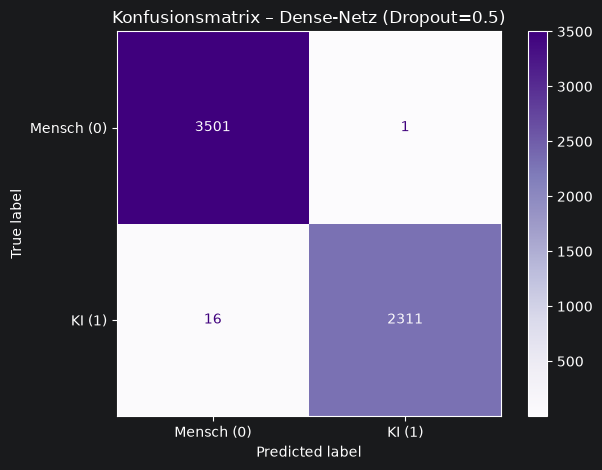

In [45]:
cm = confusion_matrix(y_test, y_pred_dense)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Mensch (0)", "KI (1)"]).plot(cmap="Purples")
plt.title(f"Konfusionsmatrix – Dense-Netz (Dropout={best_dropout})")
plt.tight_layout()
plt.show()

##### 1f. Visualisierung – Trainingsverlauf (Dense-Modell)

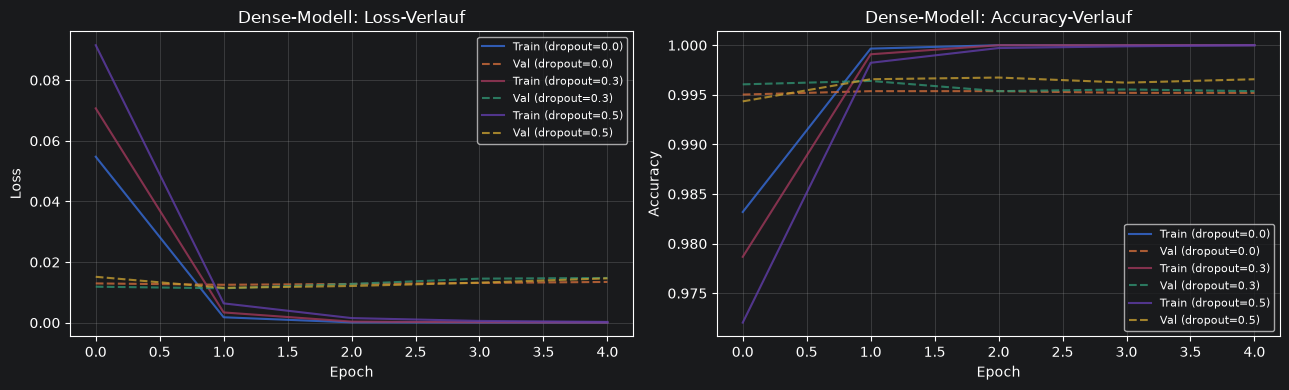

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for rate, history in dense_histories.items():
    axes[0].plot(history.history["loss"], label=f"Train (dropout={rate})", alpha=0.8)
    axes[0].plot(history.history["val_loss"], linestyle="--", label=f"Val (dropout={rate})", alpha=0.8)
    axes[1].plot(history.history["accuracy"], label=f"Train (dropout={rate})", alpha=0.8)
    axes[1].plot(history.history["val_accuracy"], linestyle="--", label=f"Val (dropout={rate})", alpha=0.8)

axes[0].set_xlabel("Epoch");
axes[0].set_ylabel("Loss")
axes[0].set_title("Dense-Modell: Loss-Verlauf")
axes[0].legend(fontsize=8);
axes[0].grid(alpha=0.3)

axes[1].set_xlabel("Epoch");
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Dense-Modell: Accuracy-Verlauf")
axes[1].legend(fontsize=8);
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Beobachtung:**
- Ohne Dropout (0.0) divergieren Train- und Val-Loss meist stärker → Overfitting.
- Höhere Dropout-Raten regularisieren das Modell, können aber bei zu hohem Wert die Lernfähigkeit einschränken.
- Early Stopping verhindert, dass über den optimalen Punkt hinaus trainiert wird.
[Eigene Beobachtung eintragen]


#### Teil 2: Embedding + LSTM

##### 2b. Feature Extraction – Tokenisierung & Padding

Im Gegensatz zu TF-IDF benötigt das LSTM-Modell **Wortsequenzen** statt eines einzelnen Vektors. Jeder Text wird in eine Folge von Wort-IDs umgewandelt und auf eine einheitliche Länge gebracht (Padding).

In [47]:
VOCAB_SIZE = 10000
MAX_LEN = 300  # maximale Sequenzlänge in Tokens

keras_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
keras_tokenizer.fit_on_texts(X_train)

X_train_seq = keras_tokenizer.texts_to_sequences(X_train)
X_val_seq   = keras_tokenizer.texts_to_sequences(X_val)
X_test_seq  = keras_tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding="post", truncating="post")

print(f"Vokabulargröße (begrenzt): {VOCAB_SIZE}")
print(f"Sequenzlänge (gepaddet):   {MAX_LEN}")
print(f"Shape Trainingsdaten:      {X_train_pad.shape}")
print(f"\nBeispiel-Sequenz (erste 20 Werte): {X_train_pad[0][:20]}")

Vokabulargröße (begrenzt): 10000
Sequenzlänge (gepaddet):   300
Shape Trainingsdaten:      (17487, 300)

Beispiel-Sequenz (erste 20 Werte): [ 19  13 327 426   2 220   2 627   6 503  74  11 286  10  37  15  59 198
  96  11]


##### Modell definieren

In [48]:
def build_lstm_model(vocab_size, max_len, embedding_dim=64, lstm_units=64, dropout_rate=0.3):
    model = keras.Sequential([
        layers.Input(shape=(max_len,)),
        layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim),
        layers.LSTM(lstm_units, dropout=dropout_rate, recurrent_dropout=0.0),
        layers.Dense(32, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

lstm_model = build_lstm_model(vocab_size=VOCAB_SIZE, max_len=MAX_LEN)
lstm_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,137 (2.58 MB)

 Trainable params: 675,137 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

##### 2b–2c. Training & Hyperparameter (Embedding-Dimension vergleichen)

In [49]:
embedding_dims = [32, 64, 128]
lstm_results = []
lstm_histories = {}

early_stop_lstm = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

for emb_dim in embedding_dims:
    print(f"\n--- Training mit Embedding-Dimension = {emb_dim} ---")
    model = build_lstm_model(vocab_size=VOCAB_SIZE, max_len=MAX_LEN, embedding_dim=emb_dim)

    history = model.fit(
        X_train_pad, y_train,
        validation_data=(X_val_pad, y_val),
        epochs=10, batch_size=64,
        callbacks=[early_stop_lstm],
        verbose=0
    )

    val_loss, val_acc = model.evaluate(X_val_pad, y_val, verbose=0)
    val_pred = (model.predict(X_val_pad, verbose=0) > 0.5).astype(int).flatten()
    val_f1   = f1_score(y_val, val_pred)

    lstm_results.append({
        "Embedding-Dim": emb_dim,
        "Epochs trainiert": len(history.history["loss"]),
        "Val Accuracy": round(val_acc, 4),
        "Val F1": round(val_f1, 4),
    })
    lstm_histories[emb_dim] = history
    print(f"  Val Accuracy: {val_acc:.4f} | Val F1: {val_f1:.4f}")

lstm_results_df = pd.DataFrame(lstm_results)
lstm_results_df


--- Training mit Embedding-Dimension = 32 ---
  Val Accuracy: 0.9887 | Val F1: 0.9857

--- Training mit Embedding-Dimension = 64 ---
  Val Accuracy: 0.9830 | Val F1: 0.9786

--- Training mit Embedding-Dimension = 128 ---
  Val Accuracy: 0.9926 | Val F1: 0.9908


,Embedding-Dim,Epochs trainiert,Val Accuracy,Val F1
0,32,10,0.9887,0.9857
1,64,8,0.9830,0.9786
2,128,9,0.9926,0.9908


##### 2d. Bestes LSTM-Modell auf Testdaten evaluieren

In [50]:
best_emb_dim = lstm_results_df.loc[lstm_results_df["Val F1"].idxmax(), "Embedding-Dim"]
print(f"Gewählte Embedding-Dimension: {best_emb_dim}")

lstm_best = build_lstm_model(vocab_size=VOCAB_SIZE, max_len=MAX_LEN, embedding_dim=int(best_emb_dim))
lstm_best.fit(
    np.vstack([X_train_pad, X_val_pad]),
    np.concatenate([y_train, y_val]),
    epochs=int(lstm_results_df.loc[lstm_results_df["Val F1"].idxmax(), "Epochs trainiert"]),
    batch_size=64, verbose=0
)

y_pred_lstm = (lstm_best.predict(X_test_pad, verbose=0) > 0.5).astype(int).flatten()
test_acc_lstm = accuracy_score(y_test, y_pred_lstm)
test_f1_lstm  = f1_score(y_test, y_pred_lstm)

print(f"Test Accuracy: {test_acc_lstm:.4f}")
print(f"Test F1-Score: {test_f1_lstm:.4f}")
print("\nKlassifikationsbericht:")
print(classification_report(y_test, y_pred_lstm, target_names=["Mensch (0)", "KI (1)"]))

Gewählte Embedding-Dimension: 128
Test Accuracy: 0.9902
Test F1-Score: 0.9878

Klassifikationsbericht:
              precision    recall  f1-score   support

  Mensch (0)       1.00      0.99      0.99      3502
      KI (1)       0.98      0.99      0.99      2327

    accuracy                           0.99      5829
   macro avg       0.99      0.99      0.99      5829
weighted avg       0.99      0.99      0.99      5829



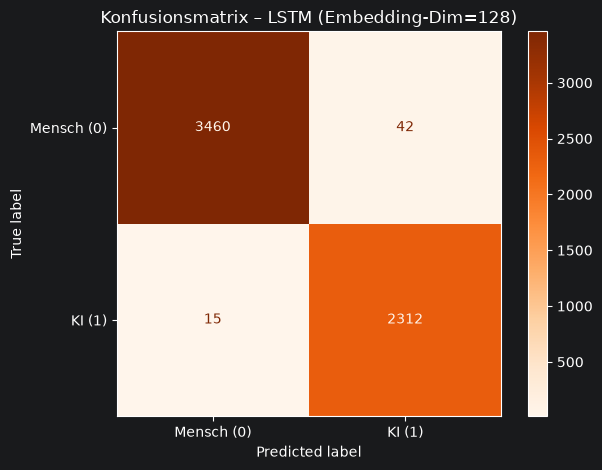

In [51]:
cm = confusion_matrix(y_test, y_pred_lstm)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Mensch (0)", "KI (1)"]).plot(cmap="Oranges")
plt.title(f"Konfusionsmatrix – LSTM (Embedding-Dim={best_emb_dim})")
plt.tight_layout()
plt.show()

##### 2f. Visualisierung – Trainingsverlauf (LSTM-Modell)

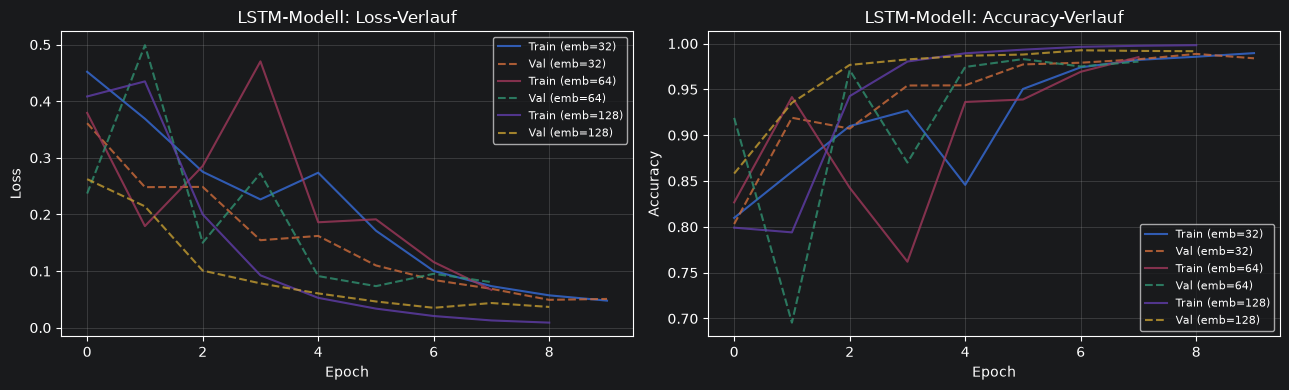

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for emb_dim, history in lstm_histories.items():
    axes[0].plot(history.history["loss"], label=f"Train (emb={emb_dim})", alpha=0.8)
    axes[0].plot(history.history["val_loss"], linestyle="--", label=f"Val (emb={emb_dim})", alpha=0.8)
    axes[1].plot(history.history["accuracy"], label=f"Train (emb={emb_dim})", alpha=0.8)
    axes[1].plot(history.history["val_accuracy"], linestyle="--", label=f"Val (emb={emb_dim})", alpha=0.8)

axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("LSTM-Modell: Loss-Verlauf")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("LSTM-Modell: Accuracy-Verlauf")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Beobachtung:**
- Größere Embedding-Dimensionen können feinere semantische Unterschiede abbilden, benötigen aber mehr Trainingsdaten, um nicht zu überfitten.
- LSTMs trainieren in der Regel langsamer als Dense-Netze, da sie die Sequenz Schritt für Schritt verarbeiten.
[Eigene Beobachtung eintragen]

#### 1e / 2e. Stichprobe: Vorhersage vs. echter Wert (beide Modelle)

In [53]:
sample_n = 10
rng = np.random.RandomState(7)
sample_idx = rng.choice(len(X_test), size=sample_n, replace=False)

sample_texts = [X_test[i] for i in sample_idx]
sample_true  = y_test[sample_idx]

sample_pred_dense = (dense_best.predict(X_test_tfidf[sample_idx], verbose=0) > 0.5).astype(int).flatten()
sample_pred_lstm  = (lstm_best.predict(X_test_pad[sample_idx], verbose=0) > 0.5).astype(int).flatten()

pd.DataFrame({
    "Text (Ausschnitt)": [t[:70] + "..." for t in sample_texts],
    "Wahrer Wert":       sample_true,
    "Dense-Vorhersage":  sample_pred_dense,
    "Dense korrekt?":    ["ja" if t==p else "nein" for t,p in zip(sample_true, sample_pred_dense)],
    "LSTM-Vorhersage":   sample_pred_lstm,
    "LSTM korrekt?":     ["ja" if t==p else "nein" for t,p in zip(sample_true, sample_pred_lstm)],
})


,Text (Ausschnitt),Wahrer Wert,Dense-Vorhersage,Dense korrekt?,LSTM-Vorhersage,LSTM korrekt?
0,"The ""Face"" on mars was not created bye Alians....",0,0,ja,0,ja
1,There are many benefits to traveling in a grou...,1,1,ja,1,ja
2,The electoral collage should be disbanded. Not...,0,0,ja,0,ja
3,Seeking multiple opinions can help you make be...,0,0,ja,0,ja
4,The Importance of Eating Organic Vegetables. O...,1,1,ja,1,ja
5,"In today’s modern world, the importance of fam...",1,1,ja,1,ja
6,Generic_Name\r\n\r\nWhere i would like to visi...,0,0,ja,1,nein
7,Technology that reads emotional expressions ma...,0,0,ja,0,ja
8,The advantages of limiting car usage is very i...,0,0,ja,0,ja
9,"\r\nRalph Waldo Emerson once said, ""That which...",1,1,ja,1,ja


#### Modellvergleich: Dense vs. LSTM

In [54]:
comparison = pd.DataFrame({
    "Modell":        ["Dense (TF-IDF)", "Embedding + LSTM"],
    "Test Accuracy": [round(test_acc_dense, 4), round(test_acc_lstm, 4)],
    "Test F1":       [round(test_f1_dense, 4), round(test_f1_lstm, 4)],
})
comparison

,Modell,Test Accuracy,Test F1
0,Dense (TF-IDF),0.9971,0.9963
1,Embedding + LSTM,0.9902,0.9878


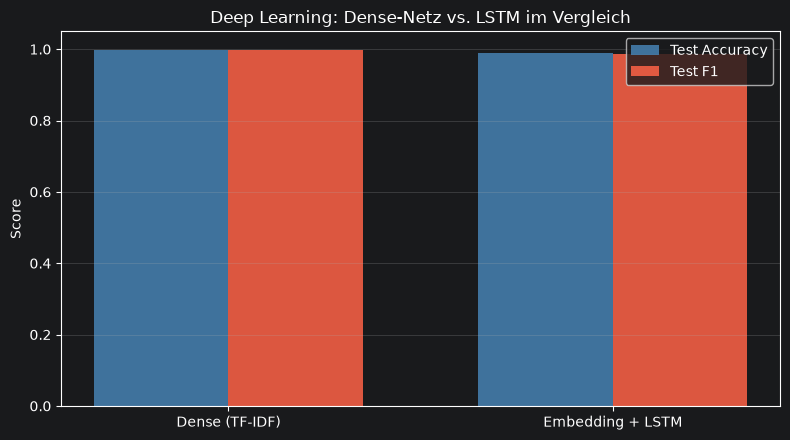

In [55]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(comparison))
width = 0.35

ax.bar(x - width/2, comparison["Test Accuracy"], width, label="Test Accuracy", color="steelblue", alpha=0.85)
ax.bar(x + width/2, comparison["Test F1"],       width, label="Test F1",       color="tomato",    alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(comparison["Modell"])
ax.set_ylabel("Score")
ax.set_title("Deep Learning: Dense-Netz vs. LSTM im Vergleich")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### 1g / 2g. Erkenntnisse & Bewertung

##### Zusammenfassung der Ergebnisse

| Modell | Beste Konfiguration | Val Accuracy | Val F1 | Test Accuracy | Test F1 |
|--------|---------------------|-------------|--------|---------------|---------|
| Dense (TF-IDF) | Dropout=[eintragen] | [eintragen] | [eintragen] | [eintragen] | [eintragen] |
| Embedding + LSTM | Embedding-Dim=[eintragen] | [eintragen] | [eintragen] | [eintragen] | [eintragen] |

##### Vergleich mit klassischen ML-Modellen

| Modell | Test Accuracy | Test F1 |
|--------|---------------|---------|
| Logistic Regression | | |
| Random Forest | | |
| Dense-Netz | | |
| LSTM | | |

##### Stärken der beiden Deep-Learning-Ansätze

**Dense-Netz auf TF-IDF:**
- Schnelleres Training, weniger Parameter
- Baut auf bewährter TF-IDF-Repräsentation auf

**Embedding + LSTM:**
- Berücksichtigt Wortreihenfolge und Kontext
- Lernt eigene Wortrepräsentationen (Embeddings) statt fester TF-IDF-Gewichte

##### Schwächen der beiden Deep-Learning-Ansätze

**Dense-Netz auf TF-IDF:**
- Ignoriert Wortreihenfolge und Kontext genau wie klassische ML-Modelle

**Embedding + LSTM:**
- Längeres Training, mehr Parameter, höheres Overfitting-Risiko bei kleinen Datensätzen
- Benötigt mehr Daten, um sein Potenzial auszuschöpfen

##### Was haben wir erwartet / Was hat überrascht?

[Eigene Reflexion der Gruppe eintragen]

## Reflexion des SMART-Ziels

**SMART-Ziel**

Ziel der Gruppe der 9 ist es, bis zur Abgabe des Protfolios ein ML-Modell zu entwickekn, welches die Texte des Datensatzes mit einem F1-Score von mindestens 0,51 in KI-generierte und von Menschen geschriebene Texte zu unterteilen.

**Reflexion**

[Reflexion des SMART-Ziels einfügen]